# Analysis of Survey for Public Works Directors across WA state government entities in non-GMA counties

## Introduction

<p>The town of White Salmon is in substantial debt, with a significant portion of that debt being related to previous water infrastructure expansion projects.<sup><a href="#fn1" id="ref1">[1]</a></sup> As the town grows and new developments are added to the existing water network, it will eventually reach capacity once again, requiring more costly expansion related expenditures.<sup><a href="#fn2" id="ref2">[2]</a></sup> Our current methods for levying water infrastructure funding are not substantial enough to meaningfully tackle the debt our town is in, and as these rates compound, so will the rates our tax base will have to absorb.<sup><a href="#fn3" id="ref3">[3]</a></sup></p>

<p>I've been tasked by the Mayor as well as members of city council to survey other towns in our predicament, in order to better understand our options.</p>

<hr>

<p id="fn1">[1] Finance Director Jennifer Neil reported the city has authorized $29.8M in infrastructure loans, with $9.9M currently outstanding — 91% of which is tied to water system upgrades. Columbia Gorge News, "White Salmon City Council talks agenda process, holds budget workshop," <a href="https://www.columbiagorgenews.com/news/white-salmon-city-council-talks-agenda-process-holds-budget-workshop/article_7a789011-b776-4851-981c-34645fb300ff.html">https://www.columbiagorgenews.com/news/white-salmon-city-council-talks-agenda-process-holds-budget-workshop/article_7a789011-b776-4851-981c-34645fb300ff.html</a> <a href="#ref1">↩</a></p>

<p id="fn2">[2] The city has $32M in planned/proposed water system modernization projects over the next 20 years to support future growth. City of White Salmon Public Works, "Water," <a href="https://www.whitesalmonwa.gov/publicworks/page/water">https://www.whitesalmonwa.gov/publicworks/page/water</a>; see also Columbia Community Connection, "White Salmon council to consider $650K water infrastructure payment," <a href="https://columbiacommunityconnection.com/the-dalles/white-salmon-council-to-consider-650k-water-infrastructure-payment">https://columbiacommunityconnection.com/the-dalles/white-salmon-council-to-consider-650k-water-infrastructure-payment</a> <a href="#ref2">↩</a></p>

<p id="fn3">[3] City Council adopted a 10% water rate increase for 2023 and 8% annual increases for 2024–2027 to fund aging infrastructure and growth needs. City of White Salmon Public Works, "Water," <a href="https://www.whitesalmonwa.gov/publicworks/page/water">https://www.whitesalmonwa.gov/publicworks/page/water</a> <a href="#ref3">↩</a></p>

[NOTE: Section "Pipeline" is where the coding / analysis portion of this jupyter notebook begins]

### Scope

Ideally, the central question we are looking to answer is "What is the best methodology for levying funds to reduce water infrastructure debt?" This question is a difficult one to answer however, given the extent of the data available to us. 

I am using the State Auditors Office's Financial Intelligence Tool (SAO FIT) to supplement the data I collected from the survey with accurate population & debt figures from 2024 for each of these towns (some of these towns are quite small and lag behind substantially on reporting these figures to the state, so I went back to the most present time that they have all reported). 

A heavily involved case-matching time series analysis would be necessary to truly measure a funding methodology's efficacy in this manner, where each town would need its population and debt (at the very least) measured across multiple years prior-to and post funding methodology adoption. This would require a substantial amount of time investment and data, of which I'm not entirely sure the SAO FIT tool would even supply for all of the towns in my survey. I am in the process of hypothetically modelling how the town of White Salmon could perform this analysis, given enough resources, time, and data access (outside of this jupyter notebook, but potentially within this repository in the future). In the meantime, I've opted for a more simplistic analysis to begin with.

With that in mind, the more answerable questions in this context are "What are other towns in our predicament doing?" & "How does a town's level of debt impact the funding mechanisms they tend to adopt?" This is what our analysis here will be focused on. Seeing what solutions other towns have come to based on their circumstances will provide us with some insight on how we can approach ours.

### Survey Population

<p>Klickitat county is what is known as a "partial-planning" county in accordance with Washington state's Growth Management Act.<sup><a href="#fn1" id="ref1">[1]</a></sup> This impacts how government entities within the county can levy fees to fund water infrastructure. Since White Salmon is located in Klickitat county, it must abide by these specifications. There are 11 total "partial planning" or "non-GMA" counties in WA state, containing 42 total towns / government entities tasked with providing water to residents.<sup><a href="#fn2" id="ref2">[2]</a></sup></p>

<p>Of these 42, 3 of them reside in Klickitat county, including White Salmon. I attempted to conduct over-the-phone interviews with 39 of these towns (not including the ones in Klickitat county, to avoid skewing the data). Of these 39, I was able to conduct 17 useful surveys with the public works directors (or other appropriate members of staff) for these different towns & Public Utilities Districts (PUD).</p>

<hr>

<p id="fn1">[1] Klickitat County has opted to "partially plan" under the GMA rather than fully plan, meaning it only adopts critical areas and natural resource lands designations rather than a full comprehensive plan. Klickitat County Planning Department, "GMA Critical Areas Update," http://www.klickitatcounty.gov/1262/GMA-Critical-Areas-Update <a href="#ref1">↩</a></p>

<p id="fn2">[2] Washington has 11 total partially-planning/non-GMA counties: Adams, Asotin, Cowlitz, Ferry, Grays Harbor, Klickitat, Lincoln, Okanogan, Skamania, Wahkiakum, and Whitman. MRSC, "Growth Management Act Basics," https://mrsc.org/explore-topics/planning/gma/growth-management-act-basics <a href="#ref2">↩</a></p>

## Abstract

White Salmon's currently insubstantial fundraising methods for their unwieldy water infrastructure debt cannot be replaced with a more flexible "Impact fee" methodology, as it is not a town within a "full-planning" Growth management act county. When looking at the current landscape surrounding alternative fundraising methods in practice, this narrows the field of comparable jurisdictions down to 42 towns and PUDs across Washington's 11 non-GMA counties. I called public works directors (or equivalent staff) at 39 of those towns outside Klickitat County and completed 17 useful interviews, a 40.5% response rate.

Using Mann-Whitney U-tests (with Benjamini-Hochberg FDR correction) and boxplots across four debt measures, I looked at which funding mechanisms correlate with town debt. System Development Charges (SDC), grants, and connection fees were the only three with enough Y/N spread to test. Population turns out to be the single strongest predictor of raw debt, so per-capita normalization matters a lot here. Once that's accounted for, SDC adoption is the most consistent finding: it's associated with higher debt across all four debt metrics, though the correlation is suggestive rather than statistically decisive at this sample size. Grants and connection fees, by contrast, flip direction depending on whether debt is measured in raw or per-capita terms, which points to their apparent relationship with debt being mostly a population artifact rather than a direct effect of the mechanism itself.

With n=17, none of this should be read as causal or conclusive. This analysis is more of a directional snapshot of what towns in a similar spot are doing, not a determination of which mechanisms reduce debt. It does, however, show that SDCs are the most dominant and consistently debt-associated tool in use among non-GMA towns, which is a useful starting point for evaluating our own options (and for extending upon these findings with a more rigorous time-series based analysis).

## The Survey

(Skip to "Survey Questions" if you don't need background info on the reasoning behind the questions)

### Background (what shaped our survey questions?)

<p>The predominant funding mechanism for infrastructure projects of any sort across "full-planning" GMA counties is known formally as an "Impact fee". When developers build new property, the town/city can specify an upfront fee on top of the development costs to offset the future cost of expanding their various utilities networks to accomodate an eventual expansion. Regulations surrounding this fee system are different from what is available to towns/cities not located in a "full planning" GMA county.<sup><a href="#fn1" id="ref1">[1]</a></sup></p>

<p>Colloquially, the town of White Salmon levy's impact fees but they are not "Impact fees" in the formal sense because that option is unavailable to them (this formal vs informal terminology surrounding funding methodology is a recurring problem). In actuality, what we have is closer to what is known more formally as a generic "connection fee". Alongside this, we use a "latecomer's agreement".<sup><a href="#fn2" id="ref2">[2]</a></sup></p>

<p>White Salmon has a population of 2,670 residents, which has grown over 10% in the last 10 years.<sup><a href="#fn3" id="ref3">[3]</a></sup> It sells/supplies fresh water to the town of Bingen, while utilizing the main waste-water system of Bingen in return.<sup><a href="#fn4" id="ref4">[4]</a></sup> It has undergone a number of major water infrastructure projects/ expansions in the last 10 years.<sup><a href="#fn5" id="ref5">[5]</a></sup> The town does not utilize a GIS tool to keep track of its water assets. 

<p>With these characteristics in mind, I opted to ask a number of questions that will show whether another town's situation is more or less similar to that of White Salmon. This will be important when considering what debt solutions are worth pursuing.

<hr>

<p id="fn1">[1] Impact fees under RCW 82.02.050–.110 are authorized only for counties, cities, and towns that plan (or choose to plan) under GMA §36.70A.040 — jurisdictions in partial-planning counties like Klickitat cannot use this mechanism (the one exception is transportation impact fees under ch. 39.92 RCW, which are available statewide). MRSC, "Impact Fees," https://mrsc.org/explore-topics/planning/administration/impact-fees; RCW 82.02.050, https://app.leg.wa.gov/rcw/default.aspx?cite=82.02.050 <a href="#ref1">↩</a></p>

<p id="fn2">[2] White Salmon's municipal code authorizes both a connection fee (a system development charge under ch. 35.92 RCW, distinct from a GMA impact fee) and separate latecomer's agreements (WSMC Ch. 13.28, most recently amended by Ordinance 2015-07-973, originally authorized under Ordinance 1996-07-634), consistent with the statutory latecomer framework in RCW 35.91.020. MRSC, "Latecomer Agreements," https://mrsc.org/explore-topics/planning/subdivisions/latecomer-agreements; City of White Salmon Ordinances, https://www.whitesalmonwa.gov/citycouncil/page/city-white-salmon-ordinances-archived <a href="#ref2">↩</a></p>

<p id="fn3">[3] Census figures show 2,224 (2010) and 2,485 (2020) — an 11.7% increase for that decade — with continued growth since, consistent with "over 10%" growth across a trailing 10-year window. World Population Review, "White Salmon, Washington Population 2026," https://worldpopulationreview.com/us-cities/washington/white-salmon <a href="#ref3">↩</a></p>

<p id="fn4">[4] White Salmon operates the water system supplying Bingen (along with the Port of Klickitat) per city ordinance addressing "Water Purchases from Bingen," while Bingen's treatment plant handles White Salmon's wastewater under a joint interlocal agreement. City of White Salmon Ordinances Archived, https://www.whitesalmonwa.gov/citycouncil/page/city-white-salmon-ordinances-archived <a href="#ref4">↩</a></p>

<p id="fn5">[5] Recent projects within the last decade include a 2019 water revenue bond anticipation note, the 2023 Phase I Transmission Main Replacement, the Spring Street Booster Pump project, and the ongoing $6M Transmission Main Phase 2B project financed through a WA Dept. of Health loan. City of White Salmon Public Works, "Water," https://www.whitesalmonwa.gov/publicworks/page/water <a href="#ref5">↩</a></p>

### Glossary (Potential Solutions & Options)

Here is a glossary for each of the potential funding mechanisms and points of interest our town is looking to learn more about in its real-world application:

System Development Charges (SDC): A one-time fee charged to a developer or property owner at the time of connection to a water or sewer system, calculated by meter/pipe size, that recovers that owner's proportional share of the system's capital cost. (Not a GMA-defined term. Authorized in Washington as a "connection charge" under RCW 35.92.025 for cities/towns<sup><a href="#fn1" id="ref1">[1]</a></sup> and RCW 57.08.005 for water-sewer districts<sup><a href="#fn2" id="ref2">[2]</a></sup>; "SDC" is a common local label for the more formally recognized connection charge / fee.)

Capital Facilities Charges (CFC): A one-time charge imposed on a new utility customer to recover their equitable share of the cost of capital infrastructure. Not defined by the GMA or any single RCW, and not a term with a fixed, statewide meaning. It falls under the same connection-charge authority as SDC/GFC, RCW 35.92.025<sup><a href="#fn1">[1]</a></sup> for cities and towns and RCW 57.08.005<sup><a href="#fn2">[2]</a></sup> for water-sewer districts, which typically treats it as one blended charge covering both existing and ten-year-planned facilities rather than splitting existing and future infrastructure into separate charges. WUTC-regulated private water companies instead use WAC 480-110-455<sup><a href="#fn3" id="ref3">[3]</a></sup>, which funds reserves for future or currently required plant improvements, not recovery of costs for infrastructure already built.

Grants: Funding awarded by a state, federal, or other outside agency to a local government for a specific capital project, typically without a repayment obligation. (Not a GMA-defined term. In Washington, infrastructure grant/loan funding is split across several programs by facility type: the Public Works Board / Public Works Assistance Account for general public works,<sup><a href="#fn4" id="ref4">[4]</a></sup> the Clean Water State Revolving Fund, administered by the Department of Ecology, for wastewater/stormwater,<sup><a href="#fn5" id="ref5">[5]</a></sup> and the Drinking Water State Revolving Fund, administered by the Department of Health, for drinking water systems.<sup><a href="#fn6" id="ref6">[6]</a></sup>)

Connection fees: A charge imposed on a property owner as a condition of connecting to a water or sewer system, covering either the physical cost of making the connection (materials, labor, meter) or the customer's equitable share of the broader system's cost, depending on how the term is used locally. (Authorized under RCW 35.92.025 for cities/towns<sup><a href="#fn1">[1]</a></sup> and RCW 57.08.005 for water-sewer districts,<sup><a href="#fn2">[2]</a></sup> which distinguish "the cost of such connection" from an additional "connection charge". However, the statute doesn't fix which term, "fee" or "charge," applies to which; that's set by local code.)

Tax rates: Instances in which a portion of a town's tax rates are explicitly allocated to funding or recouping the costs of water infrastructure. In Washington State, this occurs through four legally distinct mechanisms: general property tax levies pledged to water bond debt service; municipal utility taxes on water utility gross revenue, uncapped and subject to customer disclosure requirements<sup><a href="#fn7" id="ref7">[7]</a></sup>; special assessments via Local Improvement Districts (LIDs) or Utility Local Improvement Districts (ULIDs), which charge only directly benefiting properties rather than the town at large<sup><a href="#fn8" id="ref8">[8]</a></sup>; and direct water utility rates, which by statute must independently cover O&M and debt service<sup><a href="#fn9" id="ref9">[9]</a></sup>.

Latecomer's agreements: A contract allowing a developer who privately funds street, water, or sewer improvements to be reimbursed by other property owners who later connect to or benefit from those improvements. (Authorized under RCW 35.72.010 for street projects<sup><a href="#fn10" id="ref10">[10]</a></sup> and RCW 35.91.020 for water/sewer facilities;<sup><a href="#fn11" id="ref11">[11]</a></sup> administered outside the GMA impact fee framework.)

Impact fees: A one-time charge imposed on new development as a condition of approval, used to fund public facilities made necessary by that growth, in proportion to the development's impact. (Formally defined and authorized under the GMA at RCW 82.02.090<sup><a href="#fn12" id="ref12">[12]</a></sup> and RCW 82.02.050–.080; limited to streets/roads, parks/open space/recreation, school facilities, and fire protection facilities. Non-GMA jurisdictions cannot use this mechanism because the authorizing statute itself restricts it: RCW 82.02.050(2) grants impact fee authority only to "counties, cities, and towns that are required or choose to plan under RCW 36.70A.040,"<sup><a href="#fn13" id="ref13">[13]</a></sup><sup><a href="#fn14" id="ref14">[14]</a></sup> and subsection (5)(a) further conditions *continued* authorization on having an adopted capital facilities plan element that complies with RCW 36.70A.070, the GMA's comprehensive plan mandatory-elements statute.<sup><a href="#fn15" id="ref15">[15]</a></sup> A jurisdiction that isn't planning under the GMA has neither the RCW 36.70A.040 designation nor a 36.70A.070-compliant capital facilities plan, so it has no statutory hook under chapter 82.02 RCW to impose impact fees at all — the tool is written into the GMA framework itself, not layered on top of it.)

GIS tools: Software and data systems used to map, inventory, and analyze the location and capacity of infrastructure and facilities. (Not a legally defined term. The GMA requires a related output; an inventory of capital facilities showing locations and capacities under RCW 36.70A.070(3),<sup><a href="#fn15">[15]</a></sup> which jurisdictions commonly produce using GIS.)

<hr>

<p id="fn1">[1] RCW 35.92.025, Authority to make charges for connecting to water or sewerage system: https://app.leg.wa.gov/rcw/default.aspx?cite=35.92.025 <a href="#ref1">↩</a></p>

<p id="fn2">[2] RCW 57.08.005, Powers (water-sewer districts): https://app.leg.wa.gov/rcw/default.aspx?cite=57.08.005 <a href="#ref2">↩</a></p>

<p id="fn3">[3] WAC 480-110-455, Water company funding mechanisms: https://app.leg.wa.gov/wac/default.aspx?cite=480-110-455 <a href="#ref3">↩</a></p>

<p id="fn4">[4] Chapter 43.155 RCW, Public Works Projects — Financing: https://app.leg.wa.gov/rcw/default.aspx?cite=43.155 <a href="#ref4">↩</a></p>

<p id="fn5">[5] WA Dept. of Ecology, Water Quality Grants and Loans (Clean Water State Revolving Fund): https://ecology.wa.gov/water-shorelines/water-quality/water-quality-grants-and-loans <a href="#ref5">↩</a></p>

<p id="fn6">[6] WA Dept. of Health, Drinking Water State Revolving Fund (DWSRF): https://doh.wa.gov/community-and-environment/drinking-water/water-system-assistance/drinking-water-state-revolving-fund-dwsrf <a href="#ref6">↩</a></p>

<p id="fn7">[7] RCW 35.21.870 (utility tax authority/cap); <a href="https://app.leg.wa.gov/RCW/default.aspx?cite=35.92.460">RCW 35.92.460</a> (disclosure); <a href="https://mrsc.org/explore-topics/finance/revenues/utility-tax">MRSC – Utility Taxes</a> <a href="#ref7">↩</a></p>

<p id="fn8">[8] <a href="https://app.leg.wa.gov/rcw/default.aspx?cite=36.94.220">RCW 36.94.220</a>; <a href="https://mrsc.org/explore-topics/facilities/districts/local-improvement-districts">MRSC – Local Improvement Districts (LIDs)</a> <a href="#ref8">↩</a></p>

<p id="fn9">[9] RCW 54.24.080; <a href="https://mrsc.org/explore-topics/finance/debt/types-of-municipal-debt">MRSC – Types of Municipal Debt</a> <a href="#ref9">↩</a></p>

<p id="fn10">[10] RCW 35.72.010, Contracts authorized for street projects: https://app.leg.wa.gov/rcw/default.aspx?cite=35.72.010 <a href="#ref10">↩</a></p>

<p id="fn11">[11] RCW 35.91.020, Contracts with owners of real estate for water or sewer facilities: https://app.leg.wa.gov/rcw/default.aspx?cite=35.91.020 <a href="#ref11">↩</a></p>

<p id="fn12">[12] RCW 82.02.090, Impact fees — Definitions: https://app.leg.wa.gov/rcw/default.aspx?cite=82.02.090 <a href="#ref12">↩</a></p>

<p id="fn13">[13] RCW 82.02.050, Impact fees — Intent — Limitations: https://app.leg.wa.gov/rcw/default.aspx?cite=82.02.050 <a href="#ref13">↩</a></p>

<p id="fn14">[14] RCW 36.70A.040, Who must plan: https://app.leg.wa.gov/rcw/default.aspx?cite=36.70A.040 <a href="#ref14">↩</a></p>

<p id="fn15">[15] RCW 36.70A.070, Comprehensive plans — Mandatory elements: https://app.leg.wa.gov/rcw/default.aspx?cite=36.70A.070 <a href="#ref15">↩</a></p>

### Survey Questions

These are the questions I asked to my survey population:

"

Q1. Alright, for starters what is your formal title in relation to [city] , [name]?

Q2. Do you happen to know the GMA status of your county?

Q3. Would you say the population of [city] has grown significantly in the last 10 years?

Q4. Does your town/city sell or provide water to any neighboring towns?

Q5. Has your department needed to expand the water infrastructure for your town/city at any point in the last 10 years?

Q6. How does your department raise funds for expansions of water infrastructure? Do you levy any upfront fees, like system development charges or capacity fee charges?

Q7. How are those funding methods typically calculated? For instance, do certain factors change how much the customer or developer on your water network pays?

Q8. Does your department utilize a GIS tool for your town’s water meters? If so, is this used when calculating fees and bills?

Q9. Is there anything you would like to add that you think may be helpful on this matter?

"


The results of these surveys are located in the spreadsheet "WA_GMA_PW_Surveying Data Collection.xlsx" within the "data" folder of the repo.

Below are my methods for sourcing the data into this jupyter notebook and beginning my statistical analysis.

## Pipeline

In [2]:
import re
import pandas as pd
import numpy as np
from openpyxl import load_workbook

I want to divide the source sheet by its parent columns (Q1-Q9) into seperate data frames. This will make it easier to assemble and dissassemble the full data set around which particular survey question I gathered data from.

We loop through the top row of the sheet, detect the range of merged cells for that iteration, create a data frame for all cells below the range of merged cells (plus the first two cells on the right for every df to know county & town), add that to the return list, iterate.
This way the pipeline updates with the source as I acccumulate more data.

we can then assemble a master database from that list of dfs.

In [3]:
## Some helper functions

def pos_slicer(pos):
    new = re.findall(r'[a-zA-Z]+|:',str(pos))
    return "".join(new)

def ChildColumnsInheret_Q(df, re_InheretanceStr = r"Q\d+|EDB_\d+"):
    for col in df:
        df = df.rename(columns = {col: f"{re.findall(re_InheretanceStr, df.attrs['name'])[0]}: {col}"})
    return df

## Main

def sheet_slicer_to_df(FilName = r"../data/WA_GMA_PW_Surveying Data Collection.xlsx", sheet = "Full survey table", AlwaysCols = 'A:B', start_row = 2, ColLabels = True):
    dfs = []
    lastrng = None
    wrkb = load_workbook(FilName)
    wrks = wrkb[sheet]
    for row in wrks.iter_rows(min_row = 1, max_row = 1):
        D_itr = 0
        for cell in row:
            for merged_range in wrks.merged_cells.ranges:
                if cell.coordinate in merged_range and merged_range is lastrng:
                    break
                elif cell.coordinate in merged_range and merged_range is not lastrng:
                    lastrng = merged_range
                    rng = pos_slicer(merged_range)
                    df = pd.read_excel(
                        FilName, 
                        sheet_name = sheet, 
                        usecols = AlwaysCols + ',' + rng,
                        header = start_row - 1
                        )

                    header_txt = wrks.cell(row = merged_range.min_row, column = merged_range.min_col).value       
                    m = re.search(r"Q\d+", str(header_txt)) or re.search(r"EDB.*\d+", str(header_txt))
                    if m:
                        df.attrs['name'] = "df_" + m.group()
                    else:
                        df.attrs['name'] = f"df_Q{D_itr}"
                    
                    ## helper function for column renaming here
                    if ColLabels is True:
                        df = ChildColumnsInheret_Q(df)
                    dfs.append(df)
                    D_itr+=1
    return dfs

## A list of data frames, each a collection of data per survey question

Dfs = sheet_slicer_to_df()

## A master data frame, reassembled by combining all data frames in the list

Mdf = pd.DataFrame(Dfs[0].iloc[:, 0:2]) # first two columns

Mdf = pd.concat([Mdf] + [df_slice.iloc[:, 2:] for df_slice in Dfs], axis = 1) # get rid of duplicates

Mdf.head()

,Q0: County,Q0: Town,Q1: Useful Survey Participation <DI> (Y/N),Q1: Cleaned <IR>,Q1: Notes / Transcription [Raw] <IR>,Q2: Knowledge of GMA Status <IR> (Y/N),Q2: Notes / Transcription [Raw] <IR>.1,Q2: Fact Check [Post-Survey]: Actual County GMA status <FI>,Q3: Did Population grow in the last 10 years? <IR> (Y/N),Q3: Notes / Transcription [Raw] <IR>.2,...,"Q8: Name of GIS tool, name of separate asset valuation tool <IR>",Q9: Notes / Transcription [Raw] <IR>,Q9: Important details from secondary interviewee [usually info on who to actually interview instead of them] <IR>,Q9: Additional comments/ notes from interviewee [me] <DI>,EDB_1: Full Town Debt [Official Total Liabilities] <FI> ($),EDB_1: Full Debt per capita <CM> ($),"EDB_1: Debt to Population regression residuals [another population normalization method, got nearly the same u-test results so I left it out of the analysis] <CM> (reg residuals)","EDB_1: Capital & Bonded Debt \n[Debt-type filter, excluding pension/OPEB] <FI> ($)",EDB_1: Capital & Bonded Debt per capita <CM> ($),EDB_1: Debt figures <FI> APA 7th Edition Citations
0,Adams,Othello,Y,NaN,public works director for Othello,N,NaN,Partially Planning,Y,"9,000 now, were closer to 7,500",...,NaN,NaN,NaN,third survey,7816828.0,854.765227,-0.356649,4238690.0,463.498086,Washington State Auditor’s Office. (2024). Sch...
1,Adams,Ritzville,N,NaN,NaN,NaN,NaN,Partially Planning,NaN,NaN,...,NaN,NaN,NaN,NaN,7424624.0,4147.834637,1.325071,7316901.0,4087.654190,Washington State Auditor’s Office. (2024). Sch...
2,Asotin,Clarkston [Asotin PUD],Y,NaN,"Bob Sischo, Director of finance and administra...",N,NaN,Partially Planning,N,"Some influx during COVID, nothing significant ...",...,NaN,NaN,NaN,Good survey with the Public utilities district...,5933169.0,819.498481,-0.384146,558518.0,77.143370,Washington State Auditor’s Office. (2024). Sch...
3,Cowlitz,Longview,Y,NaN,"public works director, as well as asistant cit...",Y,non gma,*Pending,N,"not significant growth, about 1 percent averag...",...,Lucidy (asset valuation),NaN,NaN,write here after the car interview,63665714.0,1665.333874,0.220669,30408003.0,795.396364,Washington State Auditor’s Office. (2024). Sch...
4,Cowlitz,Kelso,N,NaN,NaN,NaN,NaN,*Pending,NaN,NaN,...,NaN,NaN,NaN,NaN,18018433.0,1409.893036,0.122821,10933802.0,855.540063,Washington State Auditor’s Office. (2024). Sch...


Next, I seperate out of the columns with a "Yes/No" or "Y/N" response from the master data frame.

In [4]:
## Y/N data frame

def YesNoDf (mDf = Mdf):
    YN_df = mDf.copy(deep = False)
    return pd.concat([YN_df.iloc[:, :2], YN_df.filter(regex = "(Y/N)")], axis = 1)

YnDf = YesNoDf()

## filter out non-participating towns

YnDf = YnDf[YnDf["Q1: Useful Survey Participation <DI> (Y/N)"] == 'Y']

RowNames = YnDf.columns[:2]
Data_Cols = YnDf.columns[2:]

## Coding "NR" results the same as "N/A" results

YnDf[Data_Cols] = YnDf[Data_Cols].replace('NR', np.nan)

## add a "totals" row for all non-Nan values per column

YnDf.loc['Total'] = YnDf.count()

## count of "Yes" values per column

YnDf.loc["Y count"] = (YnDf[Data_Cols] == 'Y').sum().apply(int)

## Y count / Total per column

YnDf.loc["Percentage"] = YnDf.iloc[-1].div(YnDf.iloc[-2])

display(YnDf)


,Q0: County,Q0: Town,Q1: Useful Survey Participation <DI> (Y/N),Q2: Knowledge of GMA Status <IR> (Y/N),Q3: Did Population grow in the last 10 years? <IR> (Y/N),Q3: 2024 Population Greater than median? <CM> (Y/N),Q3: Pop. growth equal to or above White Salmon's? [10.15] <CM> (Y/N),Q3: Population growth above median? [2.89] <CM> (Y/N),Q4: Selling water to other towns? <IR> (Y/N),Q4: Selling to individual customers? <IR> (Y/N),...,Q6: Other/ edge case [explicit] <DI> (Y/N),Q7: Knowledge of calculation specifics involved in funding methodology? <IR> (Y/N),Q7: Meter size [primarily] <IR> (Y/N),Q7: ERUs [primarily] <IR> (Y/N),Q7: Grandfathered / inflation adjusted <IR> (Y/N),Q7: Overall cost analysis [primarily] <IR> (Y/N),Q8: GIS tool use? <IR> (Y/N),Q8: For meter location? <IR> (Y/N),Q8: For asset valuation & fee calculations? <IR> (Y/N),Q8: Separate tool for asset valuation? <IR> (Y/N)
0,Adams,Othello,Y,N,Y,Y,Y,Y,N,N,...,N,Y,N,N,N,Y,N,NaN,NaN,NaN
2,Asotin,Clarkston [Asotin PUD],Y,N,N,Y,N,N,Y,Y,...,N,Y,N,N,N,Y,Y,Y,Y,N
3,Cowlitz,Longview,Y,Y,N,Y,N,Y,Y,N,...,N,Y,Y (fresh water connection fees),Y (sewer SDC),N,N,Y,Y,N,Y
6,Cowlitz,Woodland,Y,Y,Y,Y,Y,Y,Y,N,...,NaN,NaN,NaN,NaN,NaN,NaN,Y,Y,N,N
8,Ferry,Republic,Y,N,N,N,N,N,N,N,...,Y,NaN,NaN,NaN,NaN,NaN,Y,Y,N,N
9,Grays Harbor,Aberdeen,Y,N,N,Y,N,N,N,N,...,Y,Y,Y,N,N,N,Y,Y,N,Y
13,Grays Harbor,Elma,Y,Y,N,Y,Y,Y,N,N,...,N,Y,N,N,Y,Y,Y,Y,Y,N
19,Lincoln,Davenport,Y,NaN,Y,N,N,N,N,N,...,Y,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
23,Lincoln,Wilbur,Y,Y,N,N,N,N,N,N,...,N,N,NaN,NaN,Y,NaN,Y,N,N,N
24,Okanogan,Omak,Y,N,N,Y,N,N,N,N,...,N,N,NaN,NaN,NaN,NaN,Y,Y,Y,N


### Explaining N/A and NR responses

You'll notice that the response pools for certain questions, as well as responses within that question, are varied. This is because certain town responses are coded as "Not Applicable" (N/A) or "No Response" (NR), shrinking the number of valid responses. Here I will explain the reasoning behind these interpretations of my survey results.

#### Q5: 
There was some error on my part in not asking Jord, the City Manager of Pateros, what kind of infrastructure expansions his town had done. Therefore I left a lot of these as "No Response" or NR. I coded Palouse as NR for most reponses here because they only mentioned "updating" infrastructure as opposed to "expanding" it and I suppose I didnt press enough to get an elaboration there either. Wakiakum PUD ended up being the potential 18th interview I couldnt include in the useful survey pool, a lot of the responses are appropriately coded N/A. 

#### Q6: 
The PWD of Woodland told me that all infrastructure funding was done privately and that the private company handling their water utilities charge SDCs. They however, have nothing to do with this and do not personally collect or budget any of that money. This is in contrast with Davenport, where they still charge "right of way fees" to connect their town members to the private water system. I see this as an edge case that skews the sample pool surrounding SDC use, when we dont have any way to account for the distinction of private vs public use of SDCs. This is meant to be a survey pertaining to how local government handles debt, therefore I'm coding the responses from this town for this section of questions as N/A.

##### Q7:
Same deal here for Woodland, they dont deal with water infrastruture funding so I didnt ask them much about calculation related questions. At the time I was interviewing the PWD of Republic, I must've thought the questions pertaining to calculation knowledge werent really applicable since I didnt ask them to him. Same with Davenport. Omak PWD admitted he didnt know the calculation specifics, so the calculation specifics are rightfully coded N/A. Same with Oroville. Pateros doesnt utilize calculations for funding methods because they are maxed out on development as a whole, relying mainly on grants and loans (all coded N/A here). Same with Palouse.

#### Q8 (All but first response): 
The first coded response pertains to whether or not a town utilizes a GIS tool, the other responses pertain to how a town uses a GIS tool if they have one. Naturally the pool for the other questions is going to be smaller through use of N/A for any town that doesnt utilize GIS tools.

## Exploration (Quantitative)

### Heatmapping

Using the "Yes/No" data frame, which Y/N answers correlate to others? This heuristic will give us a better idea of what to look for.

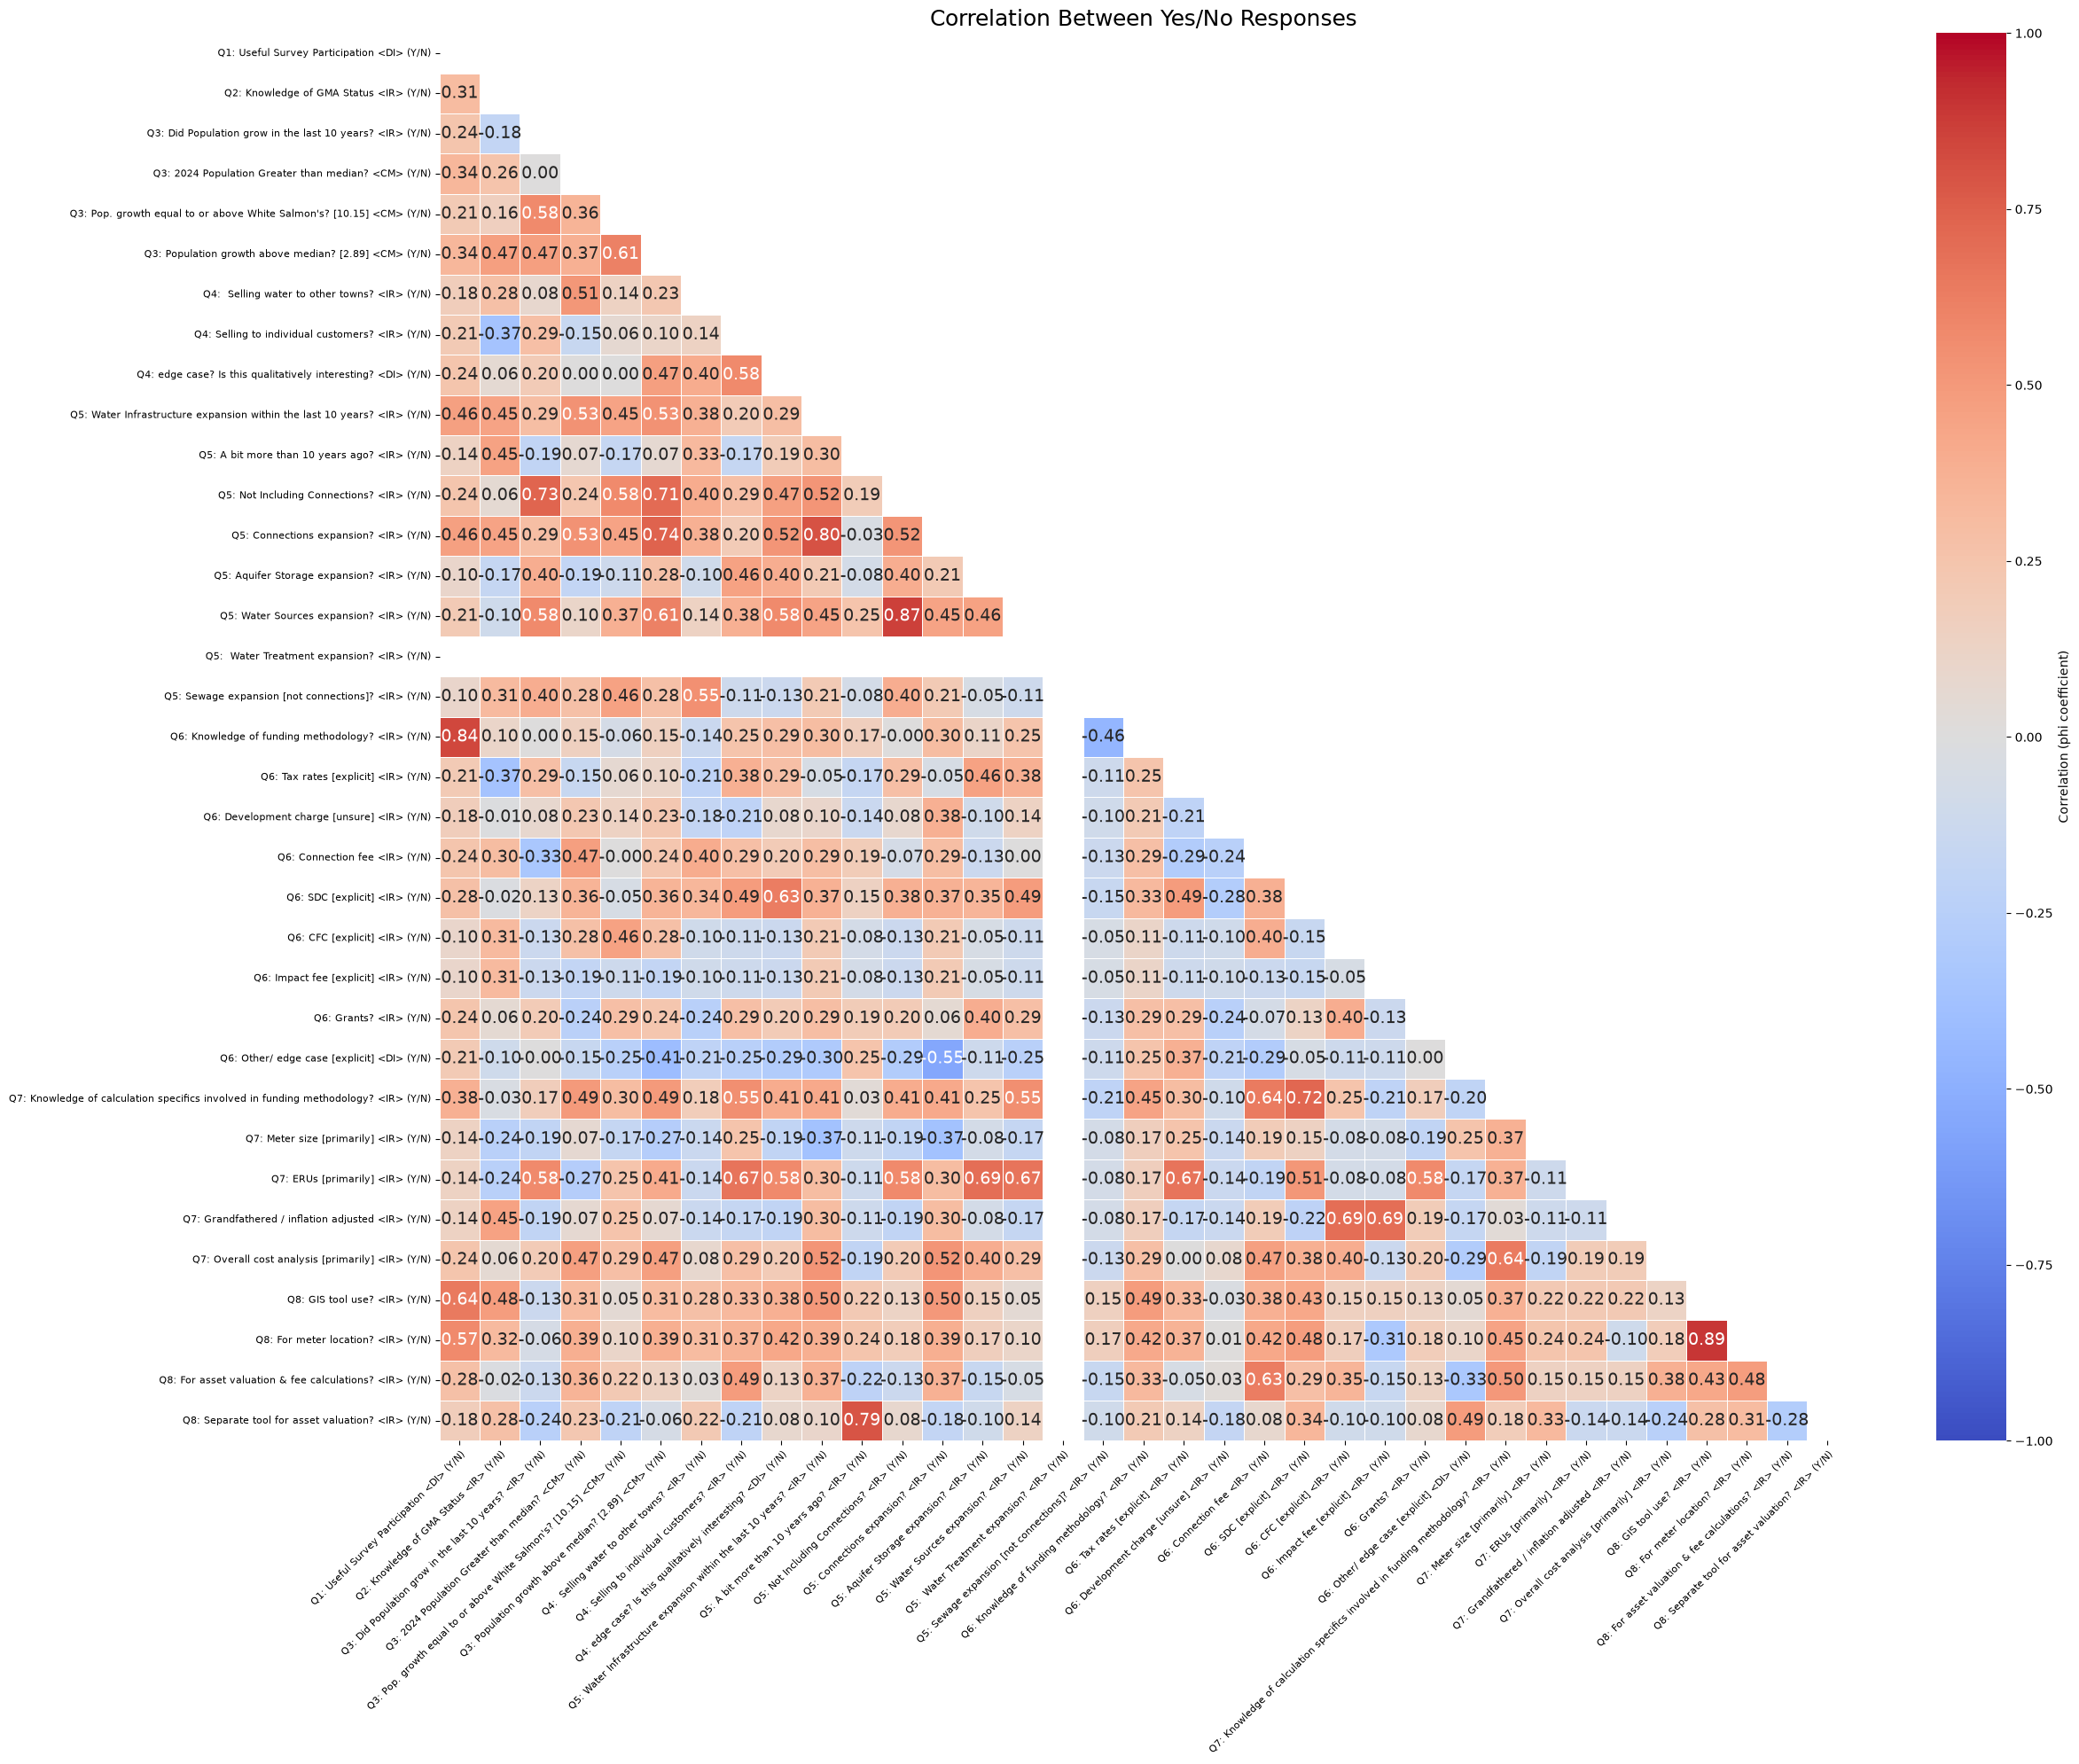


Top 8 Most Significant Correlations (no same Q pairings):

1. Q6: Knowledge of funding methodology? <IR> (Y/N) <-> Q1: Useful Survey Participation <DI> (Y/N): 0.84
2. Q8: Separate tool for asset valuation? <IR> (Y/N) <-> Q5: A bit more than 10 years ago? <IR> (Y/N): 0.79
3. Q5: Connections expansion? <IR> (Y/N) <-> Q3: Population growth above median? [2.89] <CM> (Y/N): 0.74
4. Q5: Not Including Connections? <IR> (Y/N) <-> Q3: Did Population grow in the last 10 years? <IR> (Y/N): 0.73
5. Q7: Knowledge of calculation specifics involved in funding methodology? <IR> (Y/N) <-> Q6: SDC [explicit] <IR> (Y/N): 0.72
6. Q5: Not Including Connections? <IR> (Y/N) <-> Q3: Population growth above median? [2.89] <CM> (Y/N): 0.71
7. Q7: Grandfathered / inflation adjusted <IR> (Y/N) <-> Q6: CFC [explicit] <IR> (Y/N): 0.69
8. Q7: Grandfathered / inflation adjusted <IR> (Y/N) <-> Q6: Impact fee [explicit] <IR> (Y/N): 0.69

Top 12 Most Significant Correlations Involving Q6, between Q3, Q4, and Q5:

1. Q6

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

YnDf_nums = (YnDf == "Y").astype(int)

## Correlations heatmap: between questions (columns), computed across respondents (rows)

corr = YnDf_nums.iloc[:, 2:].corr(method = "pearson")

## Mask the upper triangle (including diagonal) so each pair only appears once
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(25, 20))
ax = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 14},
    cbar_kws={"label": "Correlation (phi coefficient)"}
)

ax.tick_params(axis="both", labelsize=8)
plt.xticks(rotation=45, ha="right", rotation_mode="anchor") 
plt.yticks(rotation=0)

plt.title("Correlation Between Yes/No Responses", fontsize=18)
plt.tight_layout()
plt.show()

## Ranked list of the most significant correlations (highest to lowest, by magnitude)
pairs = (
    corr
    .where(mask == False)
    .stack()
    .rename_axis(['Q_A', 'Q_B'])
    .reset_index(name="Correlation")
)
pairs["AbsCorrelation"] = pairs["Correlation"].abs()

## Extract the "Q<number>" prefix from each question name
pairs["PrfxA"] = pairs['Q_A'].str.extract(r"(Q\d+)")
pairs["PrfxB"] = pairs['Q_B'].str.extract(r"(Q\d+)")

## Drop pairs that share the same Q-number prefix (answers derived from the same question)
pairs_diff_q = pairs[
    pairs["PrfxA"].isna() | (pairs["PrfxA"] != pairs["PrfxB"])
]

top_pairs = pairs_diff_q.sort_values("AbsCorrelation", ascending=False).head(8)

print("\nTop 8 Most Significant Correlations (no same Q pairings):\n")
for i, (_, row) in enumerate(top_pairs.iterrows(), 1):
    print(f"{i}. {row['Q_A']} <-> {row['Q_B']}: {row['Correlation']:.2f}")

## Ranked list of the most significant correlations involving Q6, paired with Q3/Q4/Q5
q6_pairs = pairs_diff_q[
    ((pairs_diff_q["PrfxA"] == "Q6") & pairs_diff_q["PrfxB"].isin({"Q3", "Q4", "Q5"}))
    | ((pairs_diff_q["PrfxB"] == "Q6") & pairs_diff_q["PrfxA"].isin({"Q3", "Q4", "Q5"}))
]
top_q6_pairs = q6_pairs.sort_values("AbsCorrelation", ascending=False).head(12)

print("\nTop 12 Most Significant Correlations Involving Q6, between Q3, Q4, and Q5:\n")
for i, (_, row) in enumerate(top_q6_pairs.iterrows(), 1):
    print(f"{i}. {row['Q_A']} <-> {row['Q_B']}: {row['Correlation']:.2f}")

Some interesting correlations to note here. Keep in mind that they are all imprecise and directional at best, mostly worth exploring further rather than taking at face value. 

SDC use shows a high correlation with unconventional water sales, and somewhat of a correlation with water source expansion & individual water sales. ERU based fee calculations are correlated with edge case water sales and expansion as well, but to a higher degree. This would make sense, considering connection fees, development charges, and SDCs are often all ERU based, making that the umbrella category.

Having an unconventional approach to levying water infrastructure funds is correlated with a lack of connections expansion, while population above median is positively correlated with connections expansion. Makes sense that the smaller towns that dont expand connections as much also dont have as formalized of a funding methodology for them.

Tax rates dedicated to water infrastructure funding are loosely correlated with Aquifer Storage expansion. So are CFC fees and population growth rates equal to/above that of White Salmon.

These observations will help guide us down the line when we have trouble interpreting our main tests.

### U-tests

In this section we conduct Mann-Whitney U-testing to see which predictors correlate highest with increased OR decreased town debt. Our statistical test here is more adequately suited to the type and sample size of our data, so it shows more accurate results than that of a basic heatmap.

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

## colors per significance tier for the bar plot
tierColors = {
    "p_fdr significant": "#1b7837",
    "raw p significant only": "#fdae61",
    "not significant": "#bbbbbb",
    "no result": "#eeeeee",
}
tier_rank = {"no result": 0, "not significant": 1, "raw p significant only": 2, "p_fdr significant": 3}
tierLegendOrder = ["p_fdr significant", "raw p significant only", "not significant", "no result"]


## Mann-Whitney U-test of each Yes/No column against compare_col

def run_u_test_analysis(
    yn_df=YnDf_nums,
    compare_col=None,
    excel_filename="utests.xlsx",
    show_plot=True,
    show_utable=False,
    min_n=5,
):
    if compare_col is None:
        compare_col = Mdf.iloc[:, -6]  ## full town debt by default

    rows, Q_Map = [], {}  ## Q_Map holds the full leave-one-out array per question, for the plot

    for colName in yn_df.columns:
        ynSeries = yn_df[colName]
        validMask = ynSeries.notna() & compare_col.notna()
        yesVals = compare_col[validMask][ynSeries[validMask] == 1].to_numpy()
        noVals = compare_col[validMask][ynSeries[validMask] == 0].to_numpy()
        nYes, nNo = len(yesVals), len(noVals)

        if nYes < min_n or nNo < min_n:  ## if group is too small, don't bother testing
            rows.append((colName, nYes, nNo, np.nan, np.nan, np.nan, np.nan, np.nan, "skip: tiny group"))
            continue

        hasTies = len(np.unique(np.concatenate([yesVals, noVals]))) != nYes + nNo
        testMethod = "asymptotic" if hasTies else "exact"
        uStat, pVal = mannwhitneyu(yesVals, noVals, alternative="two-sided", method=testMethod)
        rankBiserial = 2 * uStat / (nYes * nNo) - 1

        ## leave-one-out effect size, recomputed with one obs dropped at a time
        Q_Vals = np.array(
            [2 * mannwhitneyu(np.delete(yesVals, i), noVals).statistic / ((nYes - 1) * nNo) - 1 for i in range(nYes)]
            + [2 * mannwhitneyu(yesVals, np.delete(noVals, i)).statistic / (nYes * (nNo - 1)) - 1 for i in range(nNo)]
        )
        Q_Map[colName] = Q_Vals
        nFlips = int(np.sum(np.sign(Q_Vals) != np.sign(rankBiserial))) if rankBiserial != 0 else 0

        rows.append((colName, nYes, nNo, rankBiserial, Q_Vals.min(), Q_Vals.max(), nFlips, pVal, f"ok ({testMethod})"))

    resultsDf = pd.DataFrame(
        rows,
        columns=["question", "n_yes", "n_no", "rank_biserial", "Q_min", "Q_max", "n_sign_flips", "p", "note"],
    )
    okMask = resultsDf["note"].str.startswith("ok")
    resultsDf["p_fdr"] = np.nan
    if okMask.any():
        resultsDf.loc[okMask, "p_fdr"] = multipletests(resultsDf.loc[okMask, "p"], method="fdr_bh")[1]

    ## robust = sign holds across every leave-one-out estimate dot, fragile = it flips at least once
    resultsDf["status"] = np.where(~okMask, "no result", np.where(resultsDf["n_sign_flips"] == 0, "robust", "fragile"))

    resultsDf["tier"] = np.where(~okMask, "no result", "not significant")
    resultsDf.loc[okMask & (resultsDf["p"] < 0.05), "tier"] = "raw p significant only"
    resultsDf.loc[okMask & (resultsDf["p_fdr"] < 0.05), "tier"] = "p_fdr significant"

    resultsDf["abs_effect"] = resultsDf["rank_biserial"].abs()
    resultsDf = resultsDf.sort_values("abs_effect", ascending=False)

    resultsDf.to_excel(excel_filename, index=False)
    print(f"Results successfully saved to {excel_filename}")

    if okMask.any() and (resultsDf.loc[okMask, "n_yes"] + resultsDf.loc[okMask, "n_no"]).max() < 30:
        maxN = int((resultsDf.loc[okMask, "n_yes"] + resultsDf.loc[okMask, "n_no"]).max())
        print(
            f"Note: sample sizes here are small (max n = {maxN}) and {int(okMask.sum())} question(s) were tested. "
            "Treat results as exploratory, not confirmatory - especially anything 'fragile'."
        )

    if show_plot:
        validPlotDf = resultsDf[resultsDf["note"].str.startswith("ok")].copy()
        if validPlotDf.empty:
            print("No valid groups met the sample size threshold to generate a plot.")
        else:
            validPlotDf["_r"] = validPlotDf["tier"].map(tier_rank)
            validPlotDf = validPlotDf.sort_values(["_r", "abs_effect"]).drop(columns="_r").reset_index(drop=True)
            yPos = np.arange(len(validPlotDf))
            targetName = compare_col.name or "Target Variable"
            rng = np.random.default_rng(0)

            fig, ax = plt.subplots(figsize=(15, 0.35 * len(validPlotDf) + 1))
            ax.barh(yPos, validPlotDf["rank_biserial"], color=validPlotDf["tier"].map(tierColors), zorder=2)

            for i, row in enumerate(validPlotDf.itertuples()):
                Q_Vals = Q_Map[row.question]
                jitter = rng.uniform(-0.15, 0.15, size=len(Q_Vals))
                ax.scatter(Q_Vals, np.full(len(Q_Vals), yPos[i]) + jitter, color="black", alpha=0.4, s=10, zorder=3)  ## one dot per leave-one-out estimate

                val = row.rank_biserial
                label = f"p_fdr={row.p_fdr:.3g}"
                if val >= 0:
                    xPos, ha = max(val, row.Q_max) + 0.03, "left"
                else:
                    xPos, ha = min(val, row.Q_min) - 0.03, "right"
                ax.text(xPos, yPos[i], label, va="center", ha=ha, fontsize=9, zorder=4)

            ax.axvline(0, color="k", lw=0.8)
            ax.set_yticks(yPos)
            ax.set_yticklabels(validPlotDf["question"])
            ax.margins(x=0.25)
            ax.set_xlabel(f"Rank-biserial effect (Yes vs No on {targetName}) - dots show leave-one-out range")
            ax.set_title("Effect per Y/N question — green = p_fdr significant, amber = raw p only, gray = neither")

            legendHandles = [Patch(facecolor=tierColors[t], label=t) for t in tierLegendOrder if t in validPlotDf["tier"].unique()]
            ax.legend(handles=legendHandles, title="Significance tier", loc="lower right", fontsize=8, title_fontsize=8)

            plt.tight_layout()
            plt.show()

    if show_utable:
        tableName = os.path.splitext(os.path.basename(excel_filename))[0]
        print(f"({tableName})")
        display(resultsDf)

    return resultsDf

#### U-test graphs

<p>The primary statistical test I will be utilizing is the Mann-Whitney U-test.<sup><a href="#fn1" id="ref1">[1]</a></sup> It is a non-parametric test designed specifically to find the effect a binary response sample split ("Yes" or "No" answers for each predictor) has on a continuous or ordinal response (Monetary debt figure per town).</p>

<p>The null hypothesis is that the two groups are drawn from the same distribution; we use the test to see whether the data gives us reason to reject that. Since our sample sizes are often too small on either side of the "Yes"/"No" sample split, we cant accurately determine whether the shape of the distribution on either side is the same.<sup><a href="#fn2" id="ref2">[2]</a></sup> Therefore, we can only interpret significant results as evidence for a difference in distributions as opposed to a difference in medians between the two (i.e., towns on one side of the split tend to rank higher on debt than towns on the other).</p>

<p>Our U value measures the number of pairwise observational wins "yes" towns have over "no" towns in terms of their associated response values. We can then use the U value we obtain to calculate a ranked-biserial effect size per predictor, proportionally scaled across the board from -1 to 1.<sup><a href="#fn3" id="ref3">[3]</a></sup><sup><a href="#fn4" id="ref4">[4]</a></sup> Graphing this will show how much correlation a "Y" or "yes" response to each predictor has to our town debt measure of choice.<sup><a href="#fn5" id="ref5">[5]</a></sup></p>

<p>For a single U-test, one would follow the standard P-values to see if the results pass the null hypothesis.<sup><a href="#fn6" id="ref6">[6]</a></sup> However, we are running multiple U-tests in parallel. To avoid falsely inflating our levels of confidence, we will also use Benjamini-Hochberg False Discovery Rate (FDR) corrected p-values (P_fdr) to test against the null hypothesis.<sup><a href="#fn7" id="ref7">[7]</a></sup><sup><a href="#fn8" id="ref8">[8]</a></sup></p>

<p>Additionally, I've decided to include a "leave-one-out sensitivity check" approach. Each dot on the bars of the following graphs represent a ranked biserial effect re-calculated without one of the 17 towns included in the testing sample, doing so a total of 17 times. It wont skew p_fdr because its all calculated after the fact, mostly as a heuristic with no recorded p values per dot. The purpose of this is to show whether any one town's response to a question massively skews the effect size or directionality meaningfully. Its not to be taken as seriously as the p or p_fdr values, but its still helpful nonetheless.</p>

<p>Each graph bar is color coded by its level of confidence against the null hypothesis. Green means a correlation's p_fdr values clears the null hypothesis (P_FDR &lt; 0.05). Orange/ amber means a correlation's p_fdr value does not clear the null hypothesis (P_FDR &gt;= 0.05) but its unadjusted p-value does (P &lt; 0.05). Grey means it doesnt clear the null hypothesis on either account.</p>

<p>What you will notice across the board is that most of these bars are grey, meaning that most of these correlations are plausibly random. Despite having a large portion of our total potential sample population at 17 out of 42, a sample size of 17 (n = 17) is too small for most statistical tests to return results with a high degree of statistical power.</p>

<p>This means that there will only be a handful of tests/ predictors with a high degree of certainty in their correlations. Most of our findings here are to be taken with a grain of salt.</p>

<p>Additionally, the majority of our Q6 predictors, the ones we are most interested in seeing effect sizes for, do not have an adequate amount of observations on either side of the Y/N response to run a proper u-test on them. Grants, SDCs, and connection fees are the only exception to this rule.</p> 

<p>While this makes the comparison of all potential funding mechanisms and their relationship to town debt impossible, when our survey accounts for 40% of the entire population of municipalities that fit the bill, the difference in adoption popularity of these methodologies is a finding in and of itself. Its clear that towns mainly opt for one or more of those 3 solutions.</p>

<hr>

<p id="fn1">[1] Mann, H.B. &amp; Whitney, D.R. (1947). On a Test of Whether One of Two Random Variables is Stochastically Larger than the Other. <em>Annals of Mathematical Statistics</em>. <a href="#ref1">↩</a></p>
<p id="fn2">[2] Laerd Statistics. Assumptions of the Mann-Whitney U Test. <a href="https://statistics.laerd.com/statistical-guides/mann-whitney-u-test-assumptions.php" target="_blank" rel="noopener">statistics.laerd.com</a> <a href="#ref2">↩</a></p>
<p id="fn3">[3] Cureton, E.E. (1956). Rank-biserial correlation. <em>Psychometrika</em>. <a href="#ref3">↩</a></p>
<p id="fn4">[4] Wendt, H.W. (1972). Dealing with a common problem in social science: A simplified rank-biserial coefficient of correlation based on the U statistic. <em>European Journal of Social Psychology</em>. <a href="#ref4">↩</a></p>
<p id="fn5">[5] Kerby, D.S. (2014). The Simple Difference Formula: An Approach to Teaching Nonparametric Correlation. <em>Comprehensive Psychology</em> (SAGE). <a href="#ref5">↩</a></p>
<p id="fn6">[6] McNemar and Mann-Whitney U Tests. <em>StatPearls</em> (NCBI Bookshelf). <a href="#ref6">↩</a></p>
<p id="fn7">[7] Benjamini, Y. &amp; Hochberg, Y. (1995). Controlling the False Discovery Rate: A Practical and Powerful Approach to Multiple Testing. <em>Journal of the Royal Statistical Society, Series B</em>. <a href="#ref7">↩</a></p>
<p id="fn8">[8] Benjamini, Y. &amp; Yekutieli, D. (2001). The control of the false discovery rate in multiple testing under dependence. <em>Annals of Statistics</em>. <a href="#ref8">↩</a></p>

We will start off by measuring how each Y/N predictor correlates with full town debt.

Results successfully saved to TotalDebt_utests.xlsx
Note: sample sizes here are small (max n = 17) and 14 question(s) were tested. Treat results as exploratory, not confirmatory - especially anything 'fragile'.


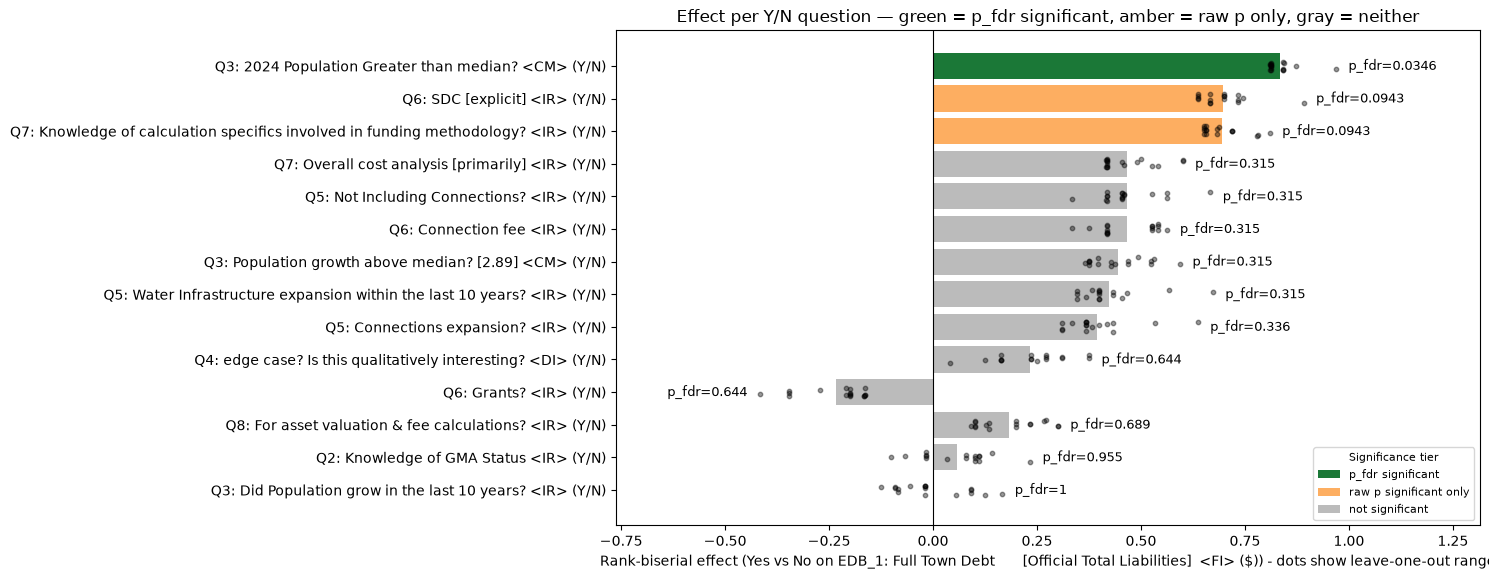

(TotalDebt_utests)


,question,n_yes,n_no,rank_biserial,Q_min,Q_max,n_sign_flips,p,note,p_fdr,status,tier,abs_effect
5,Q3: 2024 Population Greater than median? <CM> ...,8,9,0.833333,0.809524,0.968750,0.0,0.002468,ok (exact),0.034554,robust,p_fdr significant,0.833333
23,Q6: SDC [explicit] <IR> (Y/N),6,11,0.696970,0.636364,0.890909,0.0,0.020200,ok (exact),0.094268,robust,raw p significant only,0.696970
28,Q7: Knowledge of calculation specifics involve...,9,8,0.694444,0.650794,0.809524,0.0,0.015220,ok (exact),0.094268,robust,raw p significant only,0.694444
22,Q6: Connection fee <IR> (Y/N),5,12,0.466667,0.333333,0.563636,0.0,0.159987,ok (exact),0.315328,robust,not significant,0.466667
13,Q5: Not Including Connections? <IR> (Y/N),5,12,0.466667,0.333333,0.666667,0.0,0.159987,ok (exact),0.315328,robust,not significant,0.466667
32,Q7: Overall cost analysis [primarily] <IR> (Y/N),5,12,0.466667,0.416667,0.600000,0.0,0.159987,ok (exact),0.315328,robust,not significant,0.466667
7,Q3: Population growth above median? [2.89] <CM...,8,9,0.444444,0.365079,0.593750,0.0,0.138791,ok (exact),0.315328,robust,not significant,0.444444
11,Q5: Water Infrastructure expansion within the ...,11,6,0.424242,0.345455,0.672727,0.0,0.180187,ok (exact),0.315328,robust,not significant,0.424242
14,Q5: Connections expansion? <IR> (Y/N),11,6,0.393939,0.309091,0.636364,0.0,0.216063,ok (exact),0.336099,robust,not significant,0.393939
10,Q4: edge case? Is this qualitatively interesti...,5,12,0.233333,0.041667,0.375000,0.0,0.505818,ok (exact),0.643768,robust,not significant,0.233333


In [15]:
# U-testing predictor correlation with a full official debt figure

TotalDebt_utests = run_u_test_analysis(
    yn_df=YnDf_nums, 
    compare_col=Mdf.iloc[:, -6], 
    excel_filename="TotalDebt_utests.xlsx",
    show_utable=True
)

In this set of U-tests, its quite clear that our strongest correlation lies between population size and town debt. Through the research I performed prior to this analysis, I anticipated this problem, which is why I included population as a predictor to begin with. 

With full town debt as our response, it seems SDC adoption is most associated with increased town debt (outside of population), while winning grants is most heavily associated with decreased town debt (albeit with low confidence). Calculation knowledge relating to fundraising methodology is a close second. None of these ranked biserial effects pass the null hypothesis through their p_fdr value, meaning that even the ones that passed through p-values alone are suggestive rather than correlative at best.

Notice that "population growth in the last 10 years?" shows no effect size and a p_fdr = 1.0, meaning it has no correlative relationship to town debt whatsoever. This is consequence of the methodology I used for this analysis as a whole. It is not a time series analysis, therefore time series effects will not hold.

We arent looking for how population size effects debt, we want to see how funding methodology effects debt. Therefore, our next graph is the same u-test except run against a full town debt per capita figure (full debt divided by population per town).

Results successfully saved to DebtPerCapita_utests.xlsx
Note: sample sizes here are small (max n = 17) and 14 question(s) were tested. Treat results as exploratory, not confirmatory - especially anything 'fragile'.


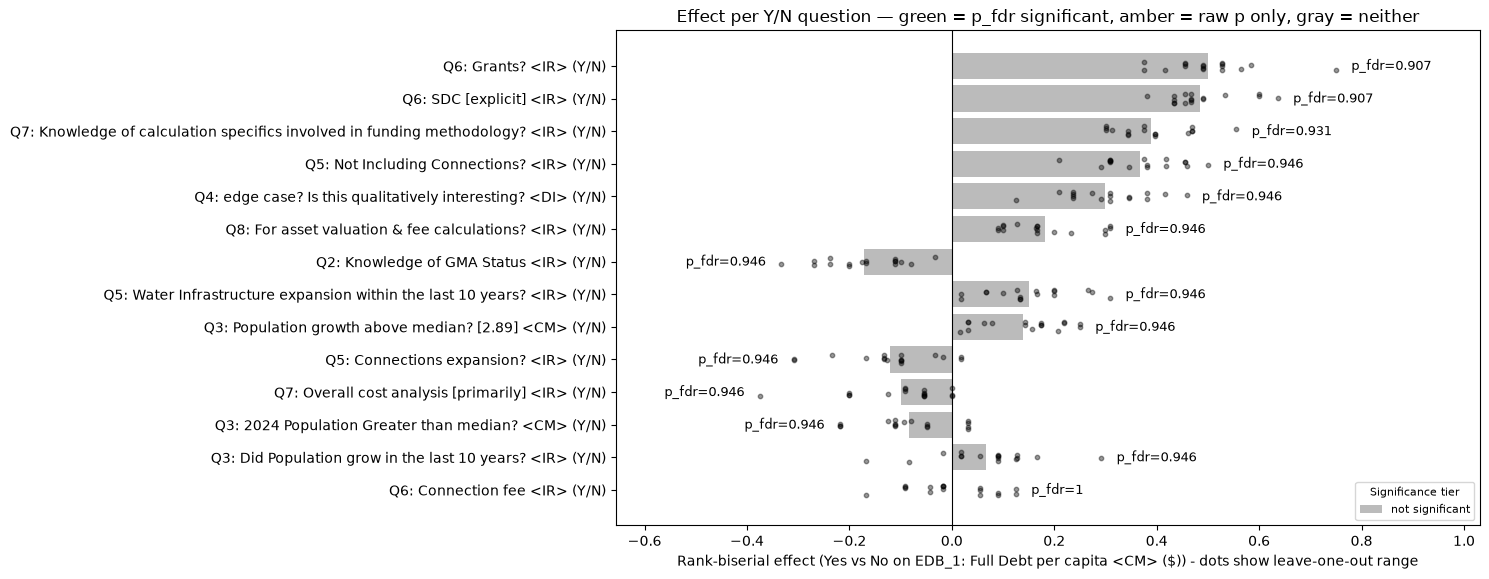

(DebtPerCapita_utests)


,question,n_yes,n_no,rank_biserial,Q_min,Q_max,n_sign_flips,p,note,p_fdr,status,tier,abs_effect
26,Q6: Grants? <IR> (Y/N),5,12,0.500000,0.375000,0.750000,0.0,0.129606,ok (exact),0.907240,robust,not significant,0.500000
23,Q6: SDC [explicit] <IR> (Y/N),6,11,0.484848,0.381818,0.636364,0.0,0.121526,ok (exact),0.907240,robust,not significant,0.484848
28,Q7: Knowledge of calculation specifics involve...,9,8,0.388889,0.301587,0.555556,0.0,0.199589,ok (exact),0.931414,robust,not significant,0.388889
13,Q5: Not Including Connections? <IR> (Y/N),5,12,0.366667,0.208333,0.500000,0.0,0.278604,ok (exact),0.946397,robust,not significant,0.366667
10,Q4: edge case? Is this qualitatively interesti...,5,12,0.300000,0.125000,0.458333,0.0,0.382676,ok (exact),0.946397,robust,not significant,0.300000
35,Q8: For asset valuation & fee calculations? <I...,6,11,0.181818,0.090909,0.309091,0.0,0.590821,ok (exact),0.946397,robust,not significant,0.181818
3,Q2: Knowledge of GMA Status <IR> (Y/N),7,10,-0.171429,-0.333333,-0.033333,0.0,0.600884,ok (exact),0.946397,robust,not significant,0.171429
11,Q5: Water Infrastructure expansion within the ...,11,6,0.151515,0.018182,0.309091,0.0,0.660472,ok (exact),0.946397,robust,not significant,0.151515
7,Q3: Population growth above median? [2.89] <CM...,8,9,0.138889,0.015873,0.250000,0.0,0.672974,ok (exact),0.946397,robust,not significant,0.138889
14,Q5: Connections expansion? <IR> (Y/N),11,6,-0.121212,-0.309091,0.018182,2.0,0.732547,ok (exact),0.946397,fragile,not significant,0.121212


In [16]:
# U-testing predictor correlation with a full official debt figure divided by the town population (full debt per capita)

DebtPerCapita_utests = run_u_test_analysis(
    yn_df=YnDf_nums, 
    compare_col=Mdf.iloc[:, -5], 
    excel_filename="DebtPerCapita_utests.xlsx",
    show_utable=True
)

Here we see a major directionality change for our correlation of grants vs response (in this case, full town debt per capita). SDC adoption stays in that 2nd most correlated spot with the response var. Connection fee use shows no directionality or correlation with debt per capita.

Note that none of these findings are statistically significant 

(Grants are likely skewed by the low population towns, despite the median distribution not showing it. More on this later).



The SAO FIT database (where I got the 2024 population and debt data from) also allows you to filter town debts by their itemized debt-type labels. Since water infrastructure debt is almost entirely comprised of capital & bonded debt, I filtered out all of the OPEB, pension, and other miscellaneous charges also associated with the town debt. This gives us an isolated "Capital & Bonded debt" figure per town. Here's what a U-test against that metric looks like

Results successfully saved to CapDebt_utests.xlsx
Note: sample sizes here are small (max n = 17) and 14 question(s) were tested. Treat results as exploratory, not confirmatory - especially anything 'fragile'.


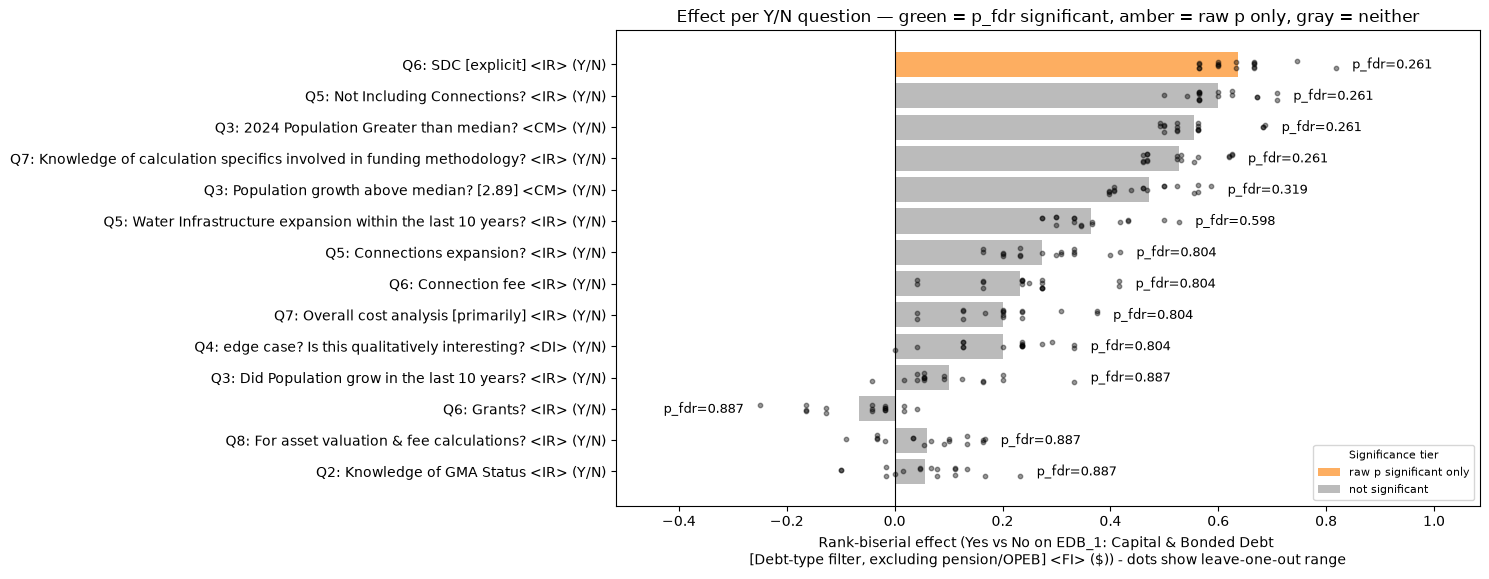

(CapDebt_utests)


,question,n_yes,n_no,rank_biserial,Q_min,Q_max,n_sign_flips,p,note,p_fdr,status,tier,abs_effect
23,Q6: SDC [explicit] <IR> (Y/N),6,11,0.636364,0.563636,0.818182,0.0,0.036522,ok (exact),0.260592,robust,raw p significant only,0.636364
13,Q5: Not Including Connections? <IR> (Y/N),5,12,0.600000,0.500000,0.709091,0.0,0.063672,ok (exact),0.260592,robust,not significant,0.600000
5,Q3: 2024 Population Greater than median? <CM> ...,8,9,0.555556,0.492063,0.687500,0.0,0.059235,ok (exact),0.260592,robust,not significant,0.555556
28,Q7: Knowledge of calculation specifics involve...,9,8,0.527778,0.460317,0.625000,0.0,0.074455,ok (exact),0.260592,robust,not significant,0.527778
7,Q3: Population growth above median? [2.89] <CM...,8,9,0.472222,0.396825,0.587302,0.0,0.113945,ok (exact),0.319046,robust,not significant,0.472222
11,Q5: Water Infrastructure expansion within the ...,11,6,0.363636,0.272727,0.527273,0.0,0.256141,ok (exact),0.597662,robust,not significant,0.363636
14,Q5: Connections expansion? <IR> (Y/N),11,6,0.272727,0.163636,0.418182,0.0,0.404331,ok (exact),0.804072,robust,not significant,0.272727
22,Q6: Connection fee <IR> (Y/N),5,12,0.233333,0.041667,0.416667,0.0,0.505818,ok (exact),0.804072,robust,not significant,0.233333
10,Q4: edge case? Is this qualitatively interesti...,5,12,0.200000,0.000000,0.333333,1.0,0.574337,ok (exact),0.804072,fragile,not significant,0.200000
32,Q7: Overall cost analysis [primarily] <IR> (Y/N),5,12,0.200000,0.041667,0.375000,0.0,0.574337,ok (exact),0.804072,robust,not significant,0.200000


In [17]:
# U-testing predictor correlation with a Capital & Bonded debt figure, all other unrelated debt charges not included

CapDebt_utests = run_u_test_analysis(
    yn_df=YnDf_nums, 
    compare_col=Mdf.iloc[:, -3], 
    excel_filename="CapDebt_utests.xlsx",
    show_utable=True
)

SDC use remains at the top, where its use is most suggestively correlated with high capital & bonded debt towns. Making this response metric change also meaningfully reduced its correlation with population.

Another good indication of our metric change's effectiveness is the second most correlated predictor, "water infrastructure expansion (not including connections) in the last 10 years". Recent water infrastructure projects are correlated with umbrella expenses encompassing water infrastructure expansion related debt, as it should be. This suggestive correlation became noticeably more significant than it was for our "Total debt" u-tests (P = 0.16 -> P = 0.06).

Below is a Capital & Bonded debt per capita set of U-tests, but none of the results are statistically significant.

Results successfully saved to CapDebtPerCapita_utests.xlsx
Note: sample sizes here are small (max n = 17) and 14 question(s) were tested. Treat results as exploratory, not confirmatory - especially anything 'fragile'.


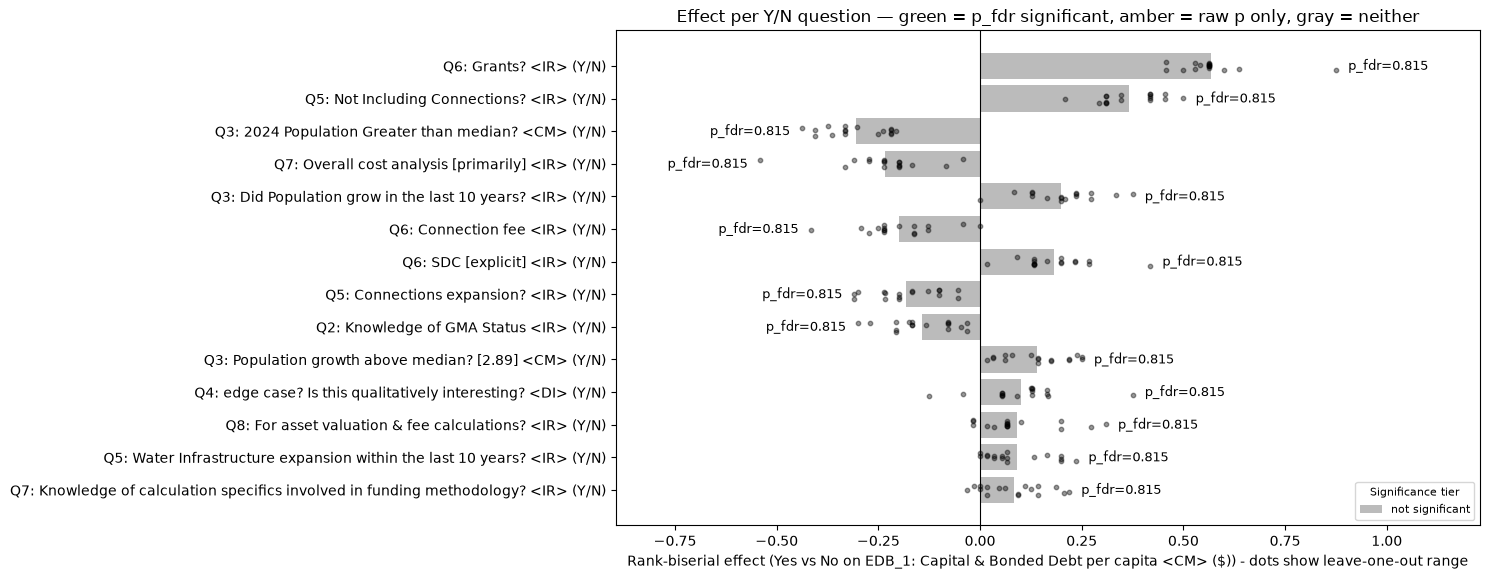

(CapDebtPerCapita_utests)


,question,n_yes,n_no,rank_biserial,Q_min,Q_max,n_sign_flips,p,note,p_fdr,status,tier,abs_effect
26,Q6: Grants? <IR> (Y/N),5,12,0.566667,0.458333,0.875000,0.0,0.081771,ok (exact),0.814809,robust,not significant,0.566667
13,Q5: Not Including Connections? <IR> (Y/N),5,12,0.366667,0.208333,0.500000,0.0,0.278604,ok (exact),0.814809,robust,not significant,0.366667
5,Q3: 2024 Population Greater than median? <CM> ...,8,9,-0.305556,-0.437500,-0.206349,0.0,0.321267,ok (exact),0.814809,robust,not significant,0.305556
32,Q7: Overall cost analysis [primarily] <IR> (Y/N),5,12,-0.233333,-0.541667,-0.041667,0.0,0.505818,ok (exact),0.814809,robust,not significant,0.233333
22,Q6: Connection fee <IR> (Y/N),5,12,-0.200000,-0.416667,0.000000,1.0,0.574337,ok (exact),0.814809,fragile,not significant,0.200000
4,Q3: Did Population grow in the last 10 years? ...,5,12,0.200000,0.000000,0.375000,1.0,0.574337,ok (exact),0.814809,fragile,not significant,0.200000
23,Q6: SDC [explicit] <IR> (Y/N),6,11,0.181818,0.018182,0.418182,0.0,0.590821,ok (exact),0.814809,robust,not significant,0.181818
14,Q5: Connections expansion? <IR> (Y/N),11,6,-0.181818,-0.309091,-0.054545,0.0,0.590821,ok (exact),0.814809,robust,not significant,0.181818
3,Q2: Knowledge of GMA Status <IR> (Y/N),7,10,-0.142857,-0.300000,-0.033333,0.0,0.669066,ok (exact),0.814809,robust,not significant,0.142857
7,Q3: Population growth above median? [2.89] <CM...,8,9,0.138889,0.015873,0.250000,0.0,0.672974,ok (exact),0.814809,robust,not significant,0.138889


In [18]:
# U-testing predictor correlation with Capital & Bonded debt per capita

CapDebtPerCapita_utests = run_u_test_analysis(
    yn_df=YnDf_nums, 
    compare_col=Mdf.iloc[:, -2], 
    excel_filename="CapDebtPerCapita_utests.xlsx",
    show_utable=True
)

You can see once again that grants changed directionality, which may indicate a relationship between grant adoption and population. Population was already controlled for somewhat by switching to the capital & bonded debt metric, so I dont see much else to point out here.

### Full U-test Summary Table

This is a consolidated summary table for SDC, grants, and connection fee u-tests across all four debt metrics (full debt, full debt per capita, cap & bond debt, cap & bond debt per capita), side by side.

In [19]:
## Consolidated SDC, Grants, and Connection fee summary across all four debt metrics

target_Qs = [
    "Q6: SDC [explicit] <IR> (Y/N)",
    "Q6: Grants? <IR> (Y/N)",
    "Q6: Connection fee <IR> (Y/N)",
]

myTables = {
    "Full Debt": TotalDebt_utests,
    "Full Debt per Capita": DebtPerCapita_utests,
    "Cap & Bonded Debt": CapDebt_utests,
    "Cap & Bonded Debt per Capita": CapDebtPerCapita_utests,
}

smry_cols = ["rank_biserial", "p", "p_fdr", "status"]

smry_pces = []
for tbl_n, res_df in myTables.items():
    piece = res_df.set_index("question").loc[target_Qs, smry_cols].copy()
    piece.columns = pd.MultiIndex.from_product([[tbl_n], piece.columns])
    smry_pces.append(piece)

utest_smry = pd.concat(smry_pces, axis=1)
utest_smry.index = utest_smry.index.str.replace(r"^Q6: ", "", regex=True)

display(utest_smry)

Full Debt                              \
                          rank_biserial         p     p_fdr  status   
question                                                              
SDC [explicit] <IR> (Y/N)      0.696970  0.020200  0.094268  robust   
Grants? <IR> (Y/N)            -0.233333  0.505818  0.643768  robust   
Connection fee <IR> (Y/N)      0.466667  0.159987  0.315328  robust   

                          Full Debt per Capita                             \
                                 rank_biserial         p    p_fdr  status   
question                                                                    
SDC [explicit] <IR> (Y/N)             0.484848  0.121526  0.90724  robust   
Grants? <IR> (Y/N)                    0.500000  0.129606  0.90724  robust   
Connection fee <IR> (Y/N)             0.000000  1.000000  1.00000  robust   

                          Cap & Bonded Debt                               \
                              rank_biserial         p     p_fdr   status   
question                                                                   
SDC [explicit] <IR> (Y/N)          0.636364  0.036522  0.260592   robust   
Grants? <IR> (Y/N)                -0.066667  0.878798  0.886775  fragile   
Connection fee <IR> (Y/N)          0.233333  0.505818  0.804072   robust   

                          Cap & Bonded Debt per Capita                      \
                                         rank_biserial         p     p_fdr   
question                                                                     
SDC [explicit] <IR> (Y/N)                     0.181818  0.590821  0.814809   
Grants? <IR> (Y/N)                            0.566667  0.081771  0.814809   
Connection fee <IR> (Y/N)                    -0.200000  0.574337  0.814809   

                                    
                            status  
question                            
SDC [explicit] <IR> (Y/N)   robust  
Grants? <IR> (Y/N)          robust  
Connection fee <IR> (Y/N)  fragile

### U-test Results & next steps

Overall while the strongest correlation is between population and full town debt, the most consistent suggestive correlation across most of the various high debt metrics is SDC use. Grants and Connection fees both reverse in directionality depending on whether the metric is population normalized (or per capita).

Upon seperating out my Q6 / funding methodology related u-test results from the rest of them (in the above table), I think its actually somewhat redundant in terms of clearly seeing where suggestively correlative relationships reside. Seeing connection fees and grants be below what should be trivial in terms of its correlation to debt (like knowledge of GMA status for instance) drives home how noisy their associated u-tests really are. It became quite clear that SDC use consistently held correlations of a higher directional magnitude than the rest of them whenever p values were significant enough to clear the noise.

For further analysis, its worth boxplotting both connection fee and grant adoption to see whether population above/below median is truly effecting the sample. I'd also look to examine SDC use Y/N boxplotted across all 4 metrics.

## Box Plots

Considering how population normalization effected correlation between our funding methodologies so heavily, below is a box plot comparing the population size per town split by their Y/N response for a given funding methodology:

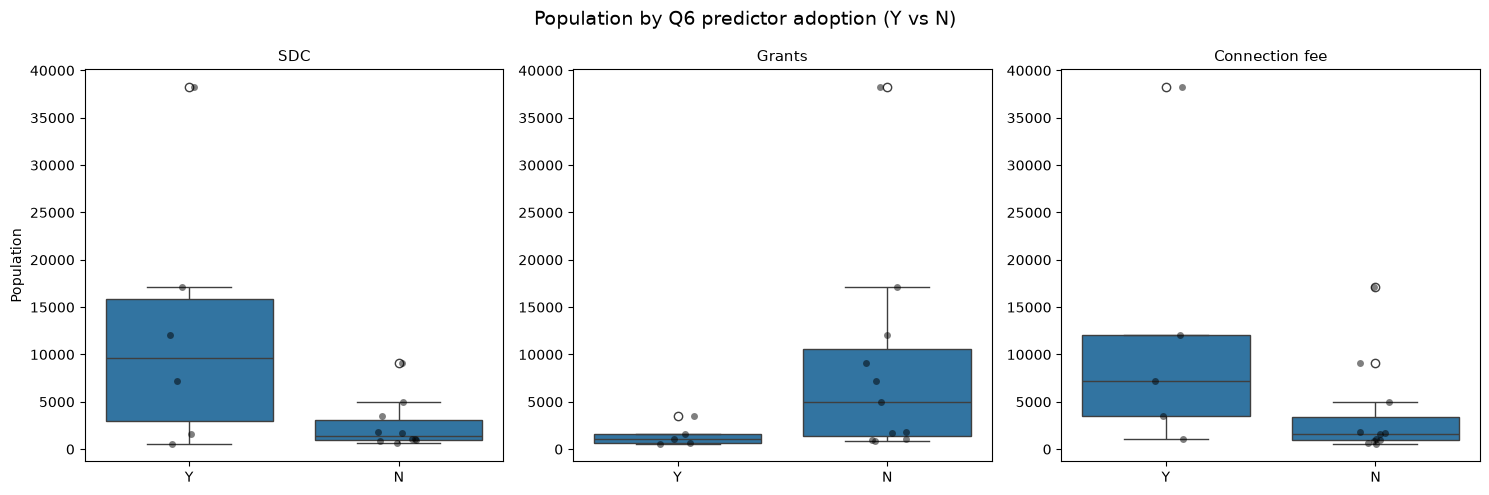

In [20]:
## Population by SDC, Grants, and Connection fee adoption (Y vs N)

predictor_cols = {
    "SDC": "Q6: SDC [explicit] <IR> (Y/N)",
    "Grants": "Q6: Grants? <IR> (Y/N)",
    "Connection fee": "Q6: Connection fee <IR> (Y/N)",
}

town_rows = YnDf.drop(index=["Total", "Y count", "Percentage"])

population_col = "Q3: 2024 Population <FI>"
population = Mdf.loc[town_rows.index, population_col]

fig, axes = plt.subplots(1, len(predictor_cols), figsize=(5 * len(predictor_cols), 5))

for ax, (label, col) in zip(axes, predictor_cols.items()):
    plot_df = pd.DataFrame({
        "value": population,
        "group": town_rows[col],
    }).dropna(subset=["value", "group"])

    sns.boxplot(data=plot_df, x="group", y="value", ax=ax, order=["Y", "N"])
    sns.stripplot(data=plot_df, x="group", y="value", ax=ax, order=["Y", "N"], color="black", alpha=0.5, jitter=True)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Population" if ax is axes[0] else "")

plt.suptitle("Population by Q6 predictor adoption (Y vs N)", fontsize=14)
plt.tight_layout()
plt.show()

Here we can see that SDC and connection fee use both have a relatively big population spread for adopters, while non-adopters are predominantly low population towns. Meanwhile, Grants are mainly awarded to towns below 2,500 residents.

SDC adoption, while mainly suggestively correlative, held the most u-test consistency across all 4 of the metrics utilized (full debt, full debt per capita, cap & bond debt, cap & bond debt per capita). Here's how that looks when we boxplot SDC adoption against those reponse metrics:

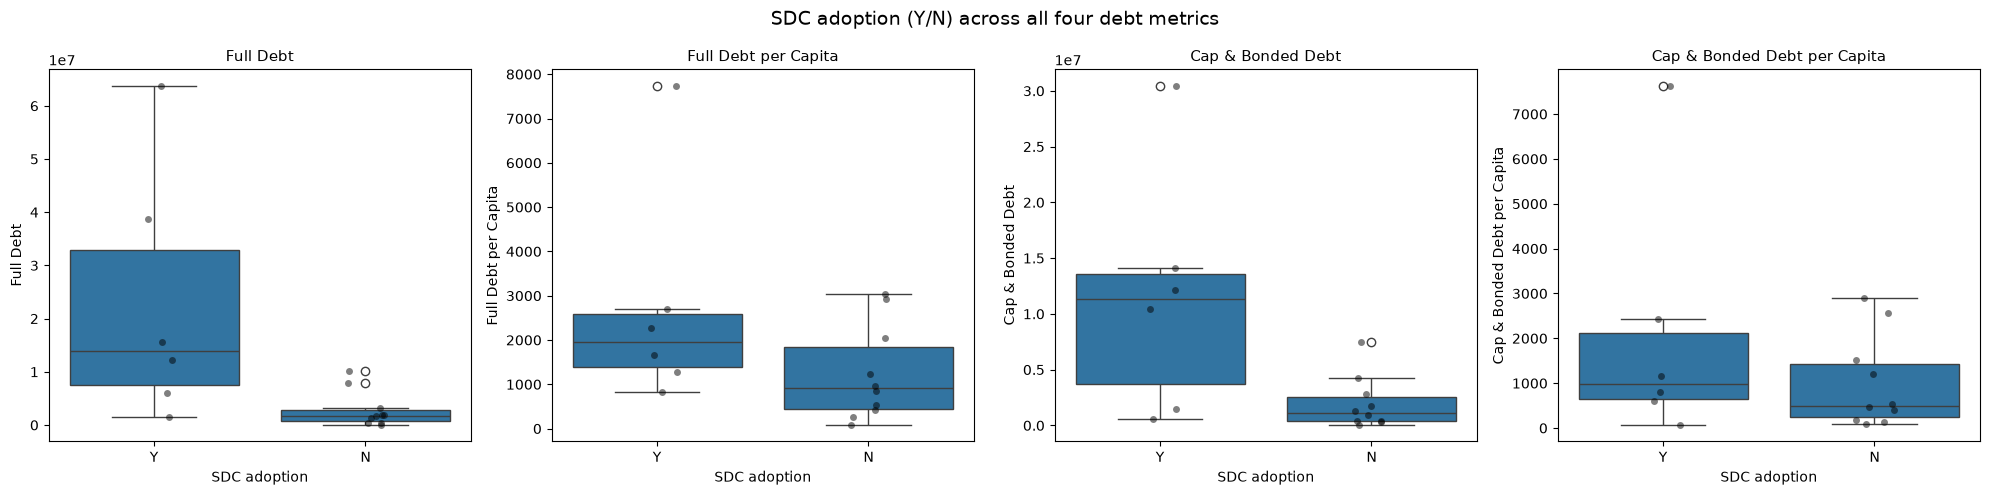

In [21]:
## SDC adoption (Y/N) boxplotted across all four debt metrics

sdc_col = "Q6: SDC [explicit] <IR> (Y/N)"

debt_metrics = {
    "Full Debt": Mdf.iloc[:, -6],
    "Full Debt per Capita": Mdf.iloc[:, -5],
    "Cap & Bonded Debt": Mdf.iloc[:, -3],
    "Cap & Bonded Debt per Capita": Mdf.iloc[:, -2],
}

sdc_group = town_rows[sdc_col]

fig, axes = plt.subplots(1, len(debt_metrics), figsize=(5 * len(debt_metrics), 5))

for ax, (label, col) in zip(axes, debt_metrics.items()):
    plot_df = pd.DataFrame({
        "value": col.loc[town_rows.index],
        "group": sdc_group,
    }).dropna(subset=["value", "group"])

    sns.boxplot(data=plot_df, x="group", y="value", ax=ax, order=["Y", "N"])
    sns.stripplot(data=plot_df, x="group", y="value", ax=ax, order=["Y", "N"], color="black", alpha=0.5, jitter=True)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("SDC adoption")
    ax.set_ylabel(label)

plt.suptitle("SDC adoption (Y/N) across all four debt metrics", fontsize=14)
plt.tight_layout()
plt.show()

There is, at the very least, a clear median difference between adopters and non-adopters of the SDC when it comes to all 4 of these debt metrics. As we saw in the U-tests, the biggest differences show when we dont account for population with both "full debt" and "cap & bonded debt". Once population is normalized, the difference is still present but scaled down.

Grants and connection fees on the other hand, were much less consistent in the directionality of their u test correlation. Below are 4 boxplots meant to show how population normalization effected these metrics, both for towns above & below the population median. (These results are harder to read, but laid out as such for the sake of comparison. Think of the orange and blue plots as completely separate graphs overlaid upon one another, simply filtered by population above or below median)

C:\Users\rowan\AppData\Local\Temp\ipykernel_28124\3735818544.py:34: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\rowan\AppData\Local\Temp\ipykernel_28124\3735818544.py:34: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\rowan\AppData\Local\Temp\ipykernel_28124\3735818544.py:34: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\rowan\AppData\Local\Temp\ipykernel_28124\3735818544.py:34: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


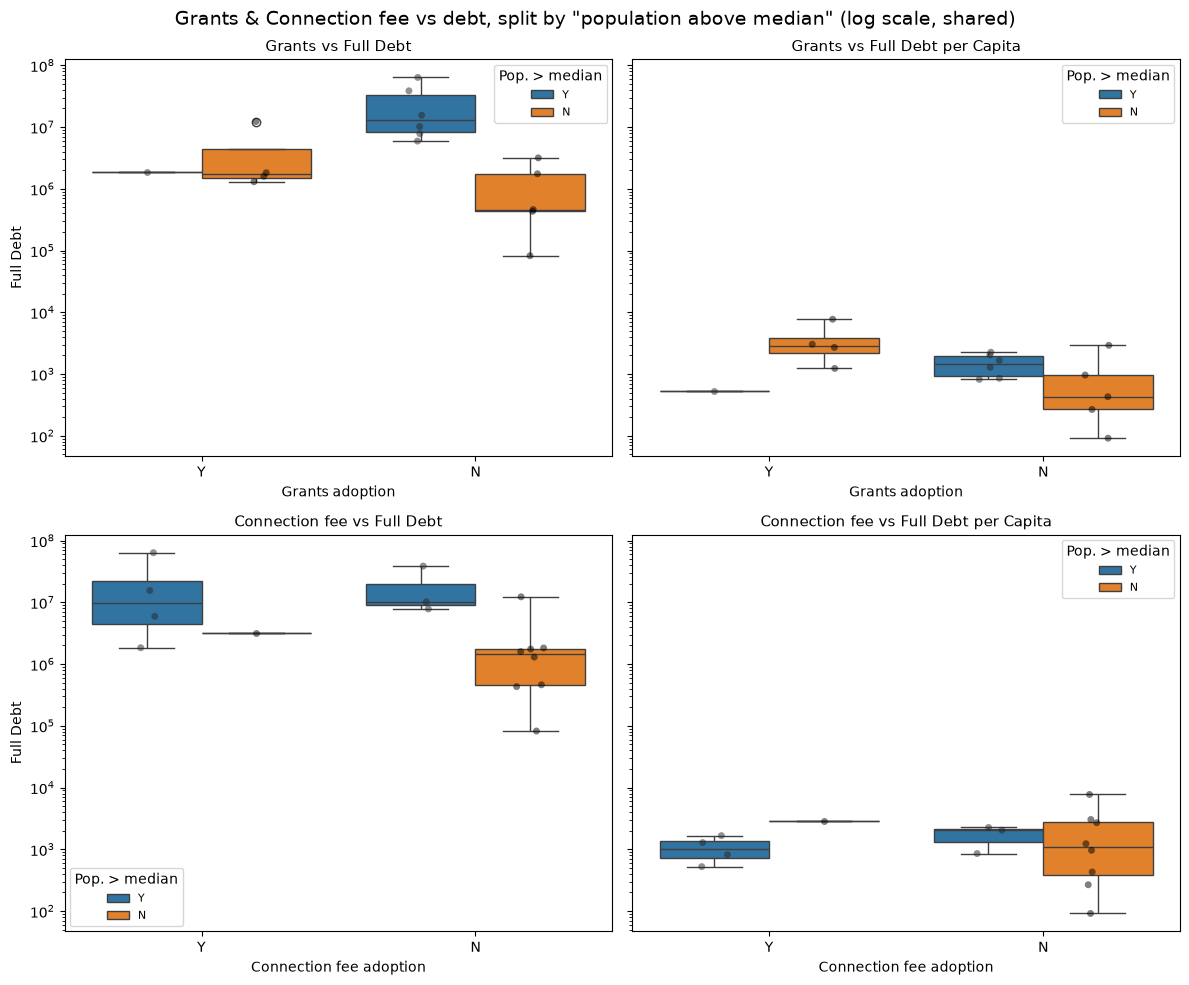

In [22]:
## Grants & Connection fee vs debt, stratified by "population above median"

predictor_cols = {
    "Grants": "Q6: Grants? <IR> (Y/N)",
    "Connection fee": "Q6: Connection fee <IR> (Y/N)",
}

pop_median_col = "Q3: 2024 Population Greater than median? <CM> (Y/N)"

debt_metrics = {
    "Full Debt": Mdf.iloc[:, -6],
    "Full Debt per Capita": Mdf.iloc[:, -5],
}

fig, axes = plt.subplots(
    len(predictor_cols), len(debt_metrics),
    figsize=(6 * len(debt_metrics), 5 * len(predictor_cols)),
    sharey=True
)

for row, (pred_label, pred_col) in enumerate(predictor_cols.items()):
    for col_idx, (debt_label, debt_col) in enumerate(debt_metrics.items()):
        ax = axes[row, col_idx]
        plot_df = pd.DataFrame({
            "value": debt_col.loc[town_rows.index],
            "predictor": town_rows[pred_col],
            "population": town_rows[pop_median_col],
        }).dropna(subset=["value", "predictor", "population"])

        sns.boxplot(
            data=plot_df, x="predictor", y="value", hue="population",
            order=["Y", "N"], hue_order=["Y", "N"], ax=ax
        )
        sns.stripplot(
            data=plot_df, x="predictor", y="value", hue="population",
            order=["Y", "N"], hue_order=["Y", "N"], dodge=True,
            color="black", alpha=0.5, jitter=True, ax=ax, legend=False
        )
        ax.set_yscale("log")
        ax.set_title(f"{pred_label} vs {debt_label}", fontsize=11)
        ax.set_xlabel(f"{pred_label} adoption")
        ax.set_ylabel(debt_label)
        ax.legend(title="Pop. > median", loc="best", fontsize=8)

plt.suptitle('Grants & Connection fee vs debt, split by "population above median" (log scale, shared)', fontsize=14)
plt.tight_layout()
plt.show()

Splitting Grants and Connection fee adoption by "population above median" confirms that population, not funding mechanism, is most correlated to differences in the full-debt columns.

In both the Grants and Connection fee panels, the "population above median" (blue) boxes sit almost entirely above the "population below median" (orange) boxes regardless of Y/N adoption status. High-population towns carry more total debt no matter how they fund infrastructure, consistent with "population above median" having a rank-biserial of 0.83 correlation with full debt from the U-tests. 

Within a given population sample, the Grants/Connection fee split stops being clean. Several of these four-way cells collapse to one or two towns (most visibly Grants == "Y" paired with "population above median", and Connection fee == "Y" paired with "population below median", both of which show as flat lines rather than boxes), so no reliable directionality can be read off this figure.

Once debt is normalized by population (using the per-capita response vars), the four groups converge into roughly the same few-hundred to few-thousand dollar band for both predictors, and the earlier population driven separation largely disappears. That explains why the per-capita U-tests came back non-significant for both Grants (p_fdr = 0.91) and Connection fee (p_fdr = 1.0). Once town size is accounted for, neither predictor shows a debt relationship this sample can distinguish from noise. 

## Non-response check

While 40.5% participation of my target survey population is quite solid, its still worth checking for "non-response bias". A devils advocate might look at these results and say "well how do you know that the population and debt distributions for most of the towns you couldnt survey arent significantly different from the towns your were able to survey?"

Here are the debt and population graphs between the towns I was and wasnt able to survey (seperated by "Q1: Useful Survey Participation <DI> (Y/N)" == Y vs N):

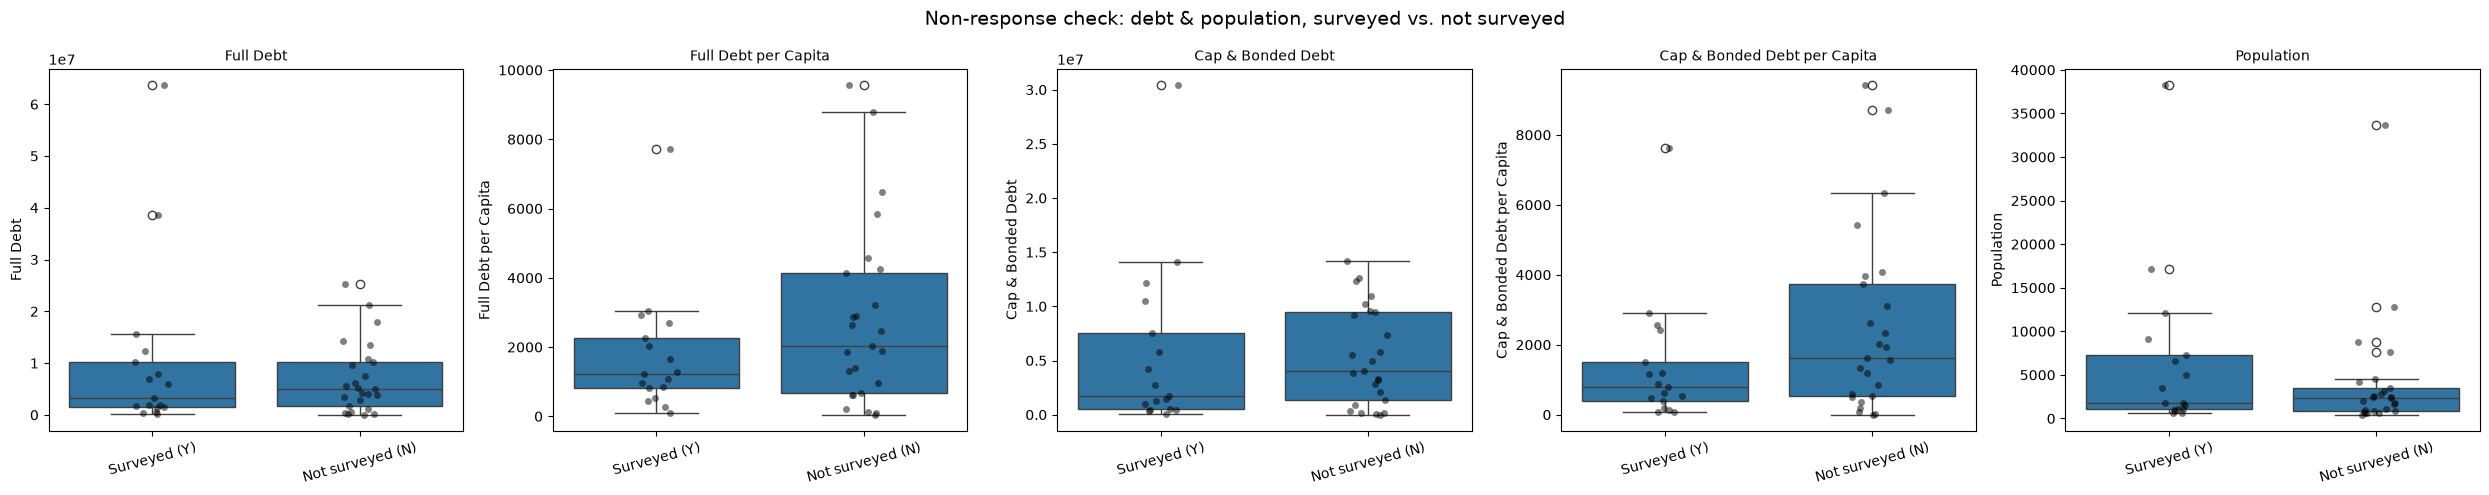

Surveyed vs. not-surveyed group comparison:

Full Debt                    n_surveyed=17  n_not=25  median_surveyed=   3,170,033.0  median_not=   5,049,557.0  p=0.939 (exact)
Full Debt per Capita         n_surveyed=17  n_not=25  median_surveyed=       1,233.2  median_not=       2,024.0  p=0.263 (exact)
Cap & Bonded Debt            n_surveyed=17  n_not=25  median_surveyed=   1,740,031.0  median_not=   4,054,132.0  p=0.63 (exact)
Cap & Bonded Debt per Capita n_surveyed=17  n_not=25  median_surveyed=         795.4  median_not=       1,612.5  p=0.138 (exact)
Population                   n_surveyed=17  n_not=25  median_surveyed=       1,815.0  median_not=       2,325.0  p=0.446 (exact)


In [23]:
## Debt & population: surveyed (Q1 = Y) vs. not-surveyed (Q1 = N) towns

respond_col = "Q1: Useful Survey Participation <DI> (Y/N)"

compare_cols = {
    "Full Debt": Mdf.iloc[:, -6],
    "Full Debt per Capita": Mdf.iloc[:, -5],
    "Cap & Bonded Debt": Mdf.iloc[:, -3],
    "Cap & Bonded Debt per Capita": Mdf.iloc[:, -2],
    "Population": Mdf["Q3: 2024 Population <FI>"],
}

group = Mdf[respond_col].apply(lambda x: "Surveyed (Y)" if x == "Y" else "Not surveyed (N)")

fig, axes = plt.subplots(1, len(compare_cols), figsize=(5 * len(compare_cols), 5))

for ax, (label, col) in zip(axes, compare_cols.items()):
    plot_df = pd.DataFrame({"value": col, "group": group}).dropna(subset=["value"])
    sns.boxplot(data=plot_df, x="group", y="value", ax=ax)
    sns.stripplot(data=plot_df, x="group", y="value", ax=ax, color="black", alpha=0.5, jitter=True)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", labelrotation=15)

plt.suptitle("Non-response check: debt & population, surveyed vs. not surveyed", fontsize=14)
plt.tight_layout()
plt.show()

## same U-test, just surveyed vs non-surveyed towns
print("Surveyed vs. not-surveyed group comparison:\n")
for label, col in compare_cols.items():
    mask = col.notna() & Mdf[respond_col].notna()
    surveyed = col[mask][Mdf[respond_col][mask] == "Y"].to_numpy()
    not_surveyed = col[mask][Mdf[respond_col][mask] != "Y"].to_numpy()
    if len(surveyed) >= 2 and len(not_surveyed) >= 2:
        tied = len(np.unique(np.concatenate([surveyed, not_surveyed]))) != len(surveyed) + len(not_surveyed)
        kind = "asymptotic" if tied else "exact"
        U, p = mannwhitneyu(surveyed, not_surveyed, alternative="two-sided", method=kind)
        print(
            f"{label:<28} n_surveyed={len(surveyed):>2}  n_not={len(not_surveyed):>2}  "
            f"median_surveyed={np.median(surveyed):>14,.1f}  median_not={np.median(not_surveyed):>14,.1f}  "
            f"p={p:.3g} ({kind})"
        )
    else:
        print(f"{label:<28} not enough data on one side to test")

None of these differences clear statistical significance (all p > 0.1), and while the surveyed group's median debt figures run somewhat lower than the non-surveyed group's across all four metrics, the gap isn't large enough to call the two groups meaningfully different.

Rest assured, this suggests the 17 towns I was able to reach aren't a systematically skewed subset of the full 42-town population, at least not along the population and debt dimensions I can measure directly.

## Conclusion

From a quantitative perspective, our findings here are mainly suggestive as opposed to being correlative. However, our non-response check shows that we were able to get a properly representative sample of the full potential survey population, with minimal non-response bias effecting our results.

U-testing shows that SDC use is generally associated with higher debt towns while grants and connection fees are more correlative to other factors like population. All of our other funding methodologies had too low of a "Y" response pool to get accurate results from a U-test. Its worth noting that these findings do not insinuate a causal relationship between town debt and SDC use, but rather one of commonality.

Simply put, SDCs are the most common funding method utilized by high debt non-GMA towns like White Salmon. So its worth further investigating why that is. I'm in the process of mapping out a hypothetical time-series analysis to be done in the future that would truly answer which funding methods are most effective in reducing water infrastructure debt.